In [3]:
import pandas as pd
measles_path = "measles_selected_cleaned.xlsx"
zonal_path = "zonal_service_availability_with_names.csv"

# Read files
measles = pd.read_excel(measles_path)
zonal = pd.read_csv(zonal_path)

# Quick confirmation
print("Measles rows, cols:", measles.shape)
print("Zonal rows, cols:", zonal.shape)


Measles rows, cols: (83436, 16)
Zonal rows, cols: (86, 12)


In [4]:
#!pip install --force-reinstall pandas==2.2.2 numpy==1.26.4 scikit-learn==1.4.2 imbalanced-learn==0.12.2 tensorflow==2.15.0 shap==0.44.1
import numpy as np
import shap
import tensorflow as tf
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("shap:", shap.__version__)
print("tensorflow:", tf.__version__)

numpy: 1.26.4
pandas: 2.2.2
shap: 0.44.1
tensorflow: 2.15.0


In [5]:
#Explore zone names: unique values and frequency (measles dataset)
# Column name in the measles file
zone_col_measles = 'Zone'

# Unique values and counts
measles_zone_counts = measles[zone_col_measles].astype(str).str.strip().value_counts(dropna=False)
print("Distinct zone strings in measles:", measles_zone_counts.shape[0])
print(measles_zone_counts.head(30))   # show top 30 most frequent

# Export unique zone names for manual inspection
measles_zone_counts.reset_index().rename(columns={'index':'zone_string', zone_col_measles:'count'}) \
    .to_csv("measles_zone_unique_counts.csv", index=False)
print("Wrote measles_zone_unique_counts.csv for manual review.")


Distinct zone strings in measles: 226
Zone
West Omo            6887
West Arsi           2461
East Wellega        2166
West Shoa           2145
South  Omo          2085
Guji                1941
Kelem Wellega       1811
Bench Sheko         1677
Hadiya              1622
Central Gonder      1580
Waghimra            1513
Eastern Sidama      1444
Fafan               1439
East Shoa           1390
South West Shoa     1388
S Omo               1295
Horo Guduru         1275
Bale                1261
Ari                 1204
Jimma               1144
Metekel             1141
Liben               1072
Gamo                1067
Kemashi             1039
Kolfe Keraniyo       972
West Guji            940
South Wello          882
West Wellega         879
Nifas Silk Lafto     865
Buno Bedele          838
Name: count, dtype: int64
Wrote measles_zone_unique_counts.csv for manual review.


In [6]:
#Explore zone names: unique values and frequency (zonal service dataset)
# Column name in your zonal file
zonal_name_col = 'zone_name'

# Unique values and counts
zonal_zone_counts = zonal[zonal_name_col].astype(str).str.strip().value_counts(dropna=False)
print("Distinct zone strings in zonal file:", zonal_zone_counts.shape[0])
print(zonal_zone_counts.head(200))   # show up to 200 zones (usually one per zone)

# Check for duplicates (same zone_name appearing more than once)
duplicates = zonal_zone_counts[zonal_zone_counts > 1]
if not duplicates.empty:
    print("Warning: these zone_name values appear more than once in the zonal file:")
    print(duplicates)
else:
    print("Each zone_name appears once (no duplicates).")

# Export zonal unique names for manual inspection
zonal_zone_counts.reset_index().rename(columns={'index':'zone_name', zonal_name_col:'count'}) \
    .to_csv("zonal_zone_unique_counts.csv", index=False)
print("Wrote zonal_zone_unique_counts.csv for manual review.")


Distinct zone strings in zonal file: 85
zone_name
gambella town                                                                       2
zone 1                                                                              1
sheka                                                                               1
silte                                                                               1
konta special                                                                       1
                                                                                   ..
east hararge                                                                        1
west hararge                                                                        1
arsi / asalla town                                                                  1
bishoft town / east shewa                                                           1
aleta chuko / aleta wondo / arbegona / aroressa / bensa / bilate zuria / bona zu    1
Name

In [7]:
#drop the v002 == 808 row and save cleaned file. Confirm the v002 column exists and drop the specific row
if 'v002' in zonal.columns:
    print("Before drop: rows =", len(zonal))
    zonal_clean = zonal[~zonal['v002'].isin([501, 808,1201])].reset_index(drop=True)
    print("After drop: rows =", len(zonal_clean))
    zonal_clean.to_csv("zonal_service_availability_with_names_cleaned.csv", index=False)
    print("Saved cleaned zonal file as zonal_service_availability_with_names_cleaned.csv")
else:
    raise KeyError("v002 column not found in zonal dataframe.")
#re-run unique-value check for zonal file
zonal_clean = pd.read_csv("zonal_service_availability_with_names_cleaned.csv")
zonal_zone_counts = zonal_clean['zone_name'].astype(str).str.strip().value_counts(dropna=False)
print("Distinct zone strings in cleaned zonal file:", zonal_zone_counts.shape[0])
print(zonal_zone_counts[zonal_zone_counts > 1])   # should be empty if duplicates removed

Before drop: rows = 86
After drop: rows = 83
Saved cleaned zonal file as zonal_service_availability_with_names_cleaned.csv
Distinct zone strings in cleaned zonal file: 83
Series([], Name: count, dtype: int64)


In [8]:
#Normalize zone strings (only basic normalization: lowercase, trim, remove punctuation, collapse spaces)
import re

def normalize_basic(s):
    if pd.isna(s):
        return ""
    s = str(s).strip().lower()    # remove punctuation
    s = re.sub(r"[^\w\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

# create normalized columns
measles['zone_norm'] = measles['Zone'].apply(normalize_basic)
zonal_clean['zone_name_norm'] = zonal_clean['zone_name'].apply(normalize_basic)

# quick check
print("Sample normalized measles zones:", measles['zone_norm'].drop_duplicates().head(10).tolist())
print("Sample normalized zonal names:", zonal_clean['zone_name_norm'].drop_duplicates().head(10).tolist())


Sample normalized measles zones: ['kefa', 'akaki kality', 'yeka', 'nifas silk lafto', 'addis ketema', 'bahir dar city', 'west arsi', 'buno bedele', 'silite', 'batu town']
Sample normalized zonal names: ['zone 1', 'zone 2', 'zone 3', 'zone 4', 'zone 5', 'unknown', 'gondar town north gondar', 'south gondar', 'north wollo', 'south wollo']


In [9]:
#Exact matching on the normalized names and count results
# build lookup of canonical zonal rows keyed by normalized name
zonal_lookup = zonal_clean.drop_duplicates(subset=['zone_name_norm']).set_index('zone_name_norm')

# initialize match columns in measles
measles['match_method'] = pd.NA
measles['zone_canonical'] = pd.NA
measles['v002'] = pd.NA

# aggregated columns to attach if exact match found
attach_cols = [
    'aggregated_zonal_child_immunization_service_availability_pct',
    'aggregated_zonal_sick_children_services_present_completed_pct',
    'aggregated_zonal_growth_monitoring_services_present_completed_pct'
]

for col in attach_cols:
    measles[col] = pd.NA

# perform exact match using normalized strings
for idx, row in measles.iterrows():
    key = row['zone_norm']
    if key in zonal_lookup.index:
        zrow = zonal_lookup.loc[key]
        # if multiple rows returned, take the first
        if isinstance(zrow, pd.DataFrame):
            zrow = zrow.iloc[0]
        measles.at[idx, 'match_method'] = 'exact'
        measles.at[idx, 'zone_canonical'] = zrow['zone_name']
        measles.at[idx, 'v002'] = zrow.get('v002', pd.NA)
        for c in attach_cols:
            if c in zrow.index:
                measles.at[idx, c] = zrow[c]
    else:
        measles.at[idx, 'match_method'] = pd.NA  # leave for later manual mapping

# diagnostics
total = len(measles)
exact_matches = measles['match_method'].eq('exact').sum()
print(f"Total rows: {total}")
print(f"Exact matches on normalized zone name: {exact_matches}")
print(f"Remaining unmatched rows: {total - exact_matches}")


Total rows: 83436
Exact matches on normalized zone name: 21512
Remaining unmatched rows: 61924


In [10]:
# assume measles, zonal_clean, and zonal_lookup already exist in the session
import pandas as pd

# compute unmatched normalized names (unique)
measles_zone_counts = measles['zone_norm'].astype(str).str.strip().value_counts()
zonal_norm_set = set(zonal_lookup.index.astype(str))

# mask of rows whose normalized zone is not in zonal canonical set
mask_unmatched = ~measles['zone_norm'].astype(str).str.strip().isin(zonal_norm_set)

# number of unique normalized names in measles and number unmatched
n_unique_measles = measles_zone_counts.shape[0]
unmatched_counts = measles_zone_counts[measles_zone_counts.index.isin(measles_zone_counts.index[mask_unmatched.groupby(measles['zone_norm']).ngroup()])]
# simpler: compute unique unmatched names and their counts
unmatched_series = measles_zone_counts[measles_zone_counts.index.to_series().apply(lambda x: x not in zonal_norm_set)]

n_unmatched_unique = unmatched_series.shape[0]

print("Unique normalized zone names in measles:", n_unique_measles)
print("Unique normalized zone names NOT found in zonal file:", n_unmatched_unique)
print("\nTop unmatched normalized names (by frequency):")
display(unmatched_series.head(50))   # show top 50; adjust as needed

# If you want the full list in the notebook:
# display(unmatched_series.sort_values(ascending=False))


Unique normalized zone names in measles: 212
Unique normalized zone names NOT found in zonal file: 186

Top unmatched normalized names (by frequency):


zone_norm
west omo                6887
west arsi               2461
west shoa               2145
bench sheko             1677
central gonder          1580
waghimra                1513
eastern sidama          1444
fafan                   1439
east shoa               1390
south west shoa         1388
s omo                   1295
horo guduru             1275
bale                    1261
ari                     1204
kemashi                 1039
kolfe keraniyo           972
west guji                940
south wello              882
nifas silk lafto         865
buno bedele              838
wolayta                  825
kefa                     805
addis ketema             796
east borena              780
sidama                   778
northern sidama          764
jarar                    755
arsi                     735
west harerghe            672
gulelle                  621
shabele                  610
yeka                     604
oromiya                  600
south gonder             598
east

In [11]:
# show canonical zonal names from zonal file
import pandas as pd
import re
# print canonical zonal zone_name_norm values as a simple comma-separated text list
zonal_norm_sorted = (
    zonal_clean[['zone_name','zone_name_norm','v002']]
    .drop_duplicates(subset=['zone_name_norm'])
    .sort_values(['zone_name_norm','zone_name'])
    .reset_index(drop=True)
)

# get the normalized names as a list and print them joined by commas
norm_list = zonal_norm_sorted['zone_name_norm'].astype(str).tolist()
print(", ".join(norm_list))

print("Canonical zonal names from zonal file (sorted). Total canonical rows:", len(zonal_norm_sorted))

abadir aboker amir nur dire teyara erer hakim unknown jinela she, adama special, addis ketema sub city, afder, agniwa, akaki kality sub city, aleta chuko aleta wondo arbegona aroressa bensa bilate zuria bona zu, amaro special bench sheko burji special derashe special goffa konso, arada sub city, arsi asalla town, assosa, awi, bahirdar town woreda, basketo special, bishoft town east shewa, bole sub city, borena, burayu town, cherkacherk factory legehare operational sabian, dawa dollo erar fafan jarar nogob shebelle sitti unknown, dawro, dessie town woreda central gondar west gondar, dukem special lega tafo lega dadhi ambo bale batu buno bedele finifi, east bale, east gojjam, east hararge, east wellega, gambella town, gamo, gedeo, gondar town north gondar, guji, gulele sub city, gurage, hadiya, hakim shenkor harari, halaba, horo gudru wellega, ilu aba bora, itang special, jimma, jimma special, kaffa, kamashi, kelem wellega, kembata tembaro, kirkos sub city unknown, kolfe keranyo subcity,

In [12]:
# Show unmatched unique normalized zone names from measles as comma-separated text

# build set of canonical normalized names
zonal_norm_set = set(zonal_clean['zone_name_norm'].astype(str))

# compute counts of unique normalized names in measles
measles_zone_counts = (
    measles['zone_norm'].astype(str).str.strip()
    .value_counts(dropna=False)
    .rename_axis('zone_norm')
    .reset_index(name='count')
)

# identify unmatched normalized names
unmatched = measles_zone_counts[~measles_zone_counts['zone_norm'].isin(zonal_norm_set)] \
    .sort_values('count', ascending=False).reset_index(drop=True)

# get the unmatched normalized names as a list and print them joined by commas
unmatched_list = unmatched['zone_norm'].astype(str).tolist()
print(", ".join(unmatched_list))

print("Unique normalized zone names NOT found in zonal file:", len(unmatched_list))


west omo, west arsi, west shoa, bench sheko, central gonder, waghimra, eastern sidama, fafan, east shoa, south west shoa, s omo, horo guduru, bale, ari, kemashi, kolfe keraniyo, west guji, south wello, nifas silk lafto, buno bedele, wolayta, kefa, addis ketema, east borena, sidama, northern sidama, jarar, arsi, west harerghe, gulelle, shabele, yeka, oromiya, south gonder, east harerghe, north wello, e gojjam, nogob, dollo, konta, southern sidama, bole, amaro special woreda, gambella, arada, itang special woreda, konso, lideta, kirkos, goffa, north west tigray, guraghe, tembaro sp woreda, w gojjam, north shewa am, w harerghe, lemi kura, finfine zuria, n shewa, central sidama, ale special woreda, west gonder, korahe, afar 1, akaki kality, e harerghe, burji, dire dawa, shashemenne town, asossa, north shoa, siti, mejenger, erer, north gonder, n wello, agnua, w arsi, wag himra, silite, hawassa city, dawa, afar 3, e shoa, shaggar city, afar 5, misrak gurage, tenbaro sp woreda, afar 4, w well

In [13]:
# Step 4: Create manual mapping dictionary and apply it

# Example manual_map: keys are unmatched measles zone_norm strings,
# values are the exact canonical zone_name strings from zonal_clean['zone_name'].
manual_map = {
    # 'measles_zone_norm': 'Canonical zone_name',
    'west arsi': 'shashemene town west arsi',
    'west shoa': 'west shewa',
    'bench sheko': 'amaro special bench sheko burji special derashe special goffa konso',
    'central gonder': 'dessie town woreda central gondar west gondar',
    'waghimra': 'waghimera',
    'eastern sidama':'aleta chuko aleta wondo arbegona aroressa bensa bilate zuria bona zu',
    'fafan': 'dawa dollo erar fafan jarar nogob shebelle sitti unknown',
    'east shoa': 'bishoft town east shewa',
    'south west shoa':'sebeta town south west shewa',
    's omo': 'south omo',
    'horo guduru': 'horo gudru wellega',
    'bale': 'east bale',
    'kemashi':'kamashi',
    'kolfe keraniyo':'kolfe keranyo subcity',
    'west guji':'guji',
    'south wello':'south wollo',
    'nifas silk lafto':'nifas silk lafto sub city',
    'buno bedele':'dukem special lega tafo lega dadhi ambo bale batu buno bedele finifi',
    'wolayta':'wolayita',
    'kefa':'kaffa',
    'addis ketema':'addis ketema sub city',
    'east borena':'borena',
    'sidama':'aleta chuko aleta wondo arbegona aroressa bensa bilate zuria bona zu',
    'northern sidama':'aleta chuko aleta wondo arbegona aroressa bensa bilate zuria bona zu',
    'jarar':'dawa dollo erar fafan jarar nogob shebelle sitti unknown',
    'arsi':'arsi asalla town',
    'west harerghe':'west hararge',
    'gulelle':'gulele sub city',
    'shabele':'dawa dollo erar fafan jarar nogob shebelle sitti unknown',
    'yeka':'yeka sub city',
    'oromiya':'oromia special',
    'south gonder':'south gondar',
    'east harerghe':'east hararge',
    'north wello':'north wollo',
    'e gojjam':'east gojjam',
    'nogob':'dawa dollo erar fafan jarar nogob shebelle sitti unknown',
    'dollo':'dawa dollo erar fafan jarar nogob shebelle sitti unknown',
    'konta':'konta special',
    'southern sidama':'aleta chuko aleta wondo arbegona aroressa bensa bilate zuria bona zu',
    'bole':'bole sub city',
    'amaro special woreda':'amaro special bench sheko burji special derashe special goffa konso',
    'gambella':'gambella town',
    'arada':'arada sub city',
    'itang special woreda':'itang special',
    'konso':'amaro special bench sheko burji special derashe special goffa konso',
    'lideta':'lideta sub city',
    'kirkos':'kirkos sub city unknown',
    'goffa':'amaro special bench sheko burji special derashe special goffa konso',
    'guraghe':'gurage',
    'tembaro sp woreda':'kembata tembaro',
    'w gojjam':'west gojjam',
    'north shewa am':'north shewa',
    'w harerghe':'west hararge',
    'finfine zuria':'dukem special lega tafo lega dadhi ambo bale batu buno bedele finifi',
    'n shewa':'north shewa',
    'central sidama':'aleta chuko aleta wondo arbegona aroressa bensa bilate zuria bona zu',
    'west gonder':'dessie town woreda central gondar west gondar',
    'korahe':'korahay',
    'akaki kality':'akaki kality sub city',
    'e harerghe':'east hararge',
    'burji':'amaro special bench sheko burji special derashe special goffa konso',
    'dire dawa':'operationals addis ketema dire dawa biyoawale gende kore jeldessa legehare',
    'shashemenne town':'shashemene town west arsi',
    'asossa':'assosa',
    'siti':'dawa dollo erar fafan jarar nogob shebelle sitti unknown',
    'afar 1':'zone 1',
    'north shoa':'north shewa',
    'mejenger':'majang',
    'erer':'dawa dollo erar fafan jarar nogob shebelle sitti unknown',
    'north gonder':'gondar town north gondar',
    'n wello':'north wollo',
    'agnua':'agniwa',
    'w arsi':'shashemene town west arsi',
    'wag himra':'waghimera',
    'silite':'silte',
    'hawassa city':'aleta chuko aleta wondo arbegona aroressa bensa bilate zuria bona zu',
    'dawa':'dawa dollo erar fafan jarar nogob shebelle sitti unknown',
    'afar 3':'zone 3',
    'e shoa':'bishoft town east shewa',
    'shaggar city':'dukem special lega tafo lega dadhi ambo bale batu buno bedele finifi',
    'afar 5':'zone 5',
    'misrak gurage':'gurage',
    'tenbaro sp woreda':'kembata tembaro',
    'afar 4':'zone 4',
    'w wellega':'west wellega',
    'kembata':'kembata tembaro',
    'n shoa':'north shewa sululta town',
    'debre berhan town':'north shewa',
    's gonder':'south gondar',
    'nekemte town':'east wellega',
    'south west shewa':'sebeta town south west shewa',
    'hareri':'hakim shenkor harari',
    'asosa':'assosa',
    'asela town':'arsi asalla town',
    'gambela town':'gambella town',
    'aboker':'abadir aboker amir nur dire teyara erer hakim unknown jinela she',
    'abadir':'abadir aboker amir nur dire teyara erer hakim unknown jinela she',
    'dire teyara':'abadir aboker amir nur dire teyara erer hakim unknown jinela she',
    'gondar city':'gondar town north gondar',
    'gondar town':'gondar town north gondar',
    'bishoftu town':'bishoft town east shewa',
    'c gonder':'dessie town woreda central gondar west gondar',
    'shashemene town':'shashemene town west arsi',
    'e wellega':'east wellega',
    'dessie town':'dessie town woreda central gondar west gondar',
    'central gondar':'dessie town woreda central gondar west gondar',
    'hakim':'abadir aboker amir nur dire teyara erer hakim unknown jinela she',
    'w shoa':'west shewa',
    'w gonder':'dessie town woreda central gondar west gondar',
    'amir nur':'abadir aboker amir nur dire teyara erer hakim unknown jinela she',
    'hawassa ca':'aleta chuko aleta wondo arbegona aroressa bensa bilate zuria bona zu',
    'afar 2':'zone 2',
    'sofi':'abadir aboker amir nur dire teyara erer hakim unknown jinela she',
    'adama town':'adama special',
    'basketo':'basketo special',
    'burji special woreda':'amaro special bench sheko burji special derashe special goffa konso',
    'derashe special woreda':'amaro special bench sheko burji special derashe special goffa konso',
    'n gonder':'gondar town north gondar',
    'biyoawale':'operationals addis ketema dire dawa biyoawale gende kore jeldessa legehare',
    'gende kore':'operationals addis ketema dire dawa biyoawale gende kore jeldessa legehare',
    'legehare':'operationals addis ketema dire dawa biyoawale gende kore jeldessa legehare',
    'west omo':'south omo',
    'robe town':'east bale',
    'yem':'yem special',
    's wello':'south wollo',
    'maya city':'east hararge',
    'ari':'south omo',
    'sw shoa':'sebeta town south west shewa',
    'batu town':'dukem special lega tafo lega dadhi ambo bale batu buno bedele finifi',
    'woliso town':'sebeta town south west shewa',
    'w guji':'guji',
    'bahir dar city':'bahirdar town woreda',
    'bahir dar town':'bahirdar town woreda',
    'sabian':'cherkacherk factory legehare operational sabian',
    'holeta town':'west shewa',
    'erer h':'abadir aboker amir nur dire teyara erer hakim unknown jinela she',
    'kombolcha town':'south wollo',
    'jimma town':'jimma',
    'bule hora town':'guji',
    'dukem town':'dukem special lega tafo lega dadhi ambo bale batu buno bedele finifi',
    'melkajebdu':'operationals addis ketema dire dawa biyoawale gende kore jeldessa legehare',
    'weliso town':'sebeta town south west shewa',
    'woldia town':'north wollo',
    'lemi kura':'bole sub city',
    'mareko sp woreda':'gurage',
    'kebena sp woreda':'gurage',
    'north gojjam':'west gojjam',
    'mojo town':'bishoft town east shewa',
    'modjo town':'bishoft town east shewa',
    'metu town':'ilu aba bora',
    'dessie city':'dessie town woreda central gondar west gondar',
    'ambo town':'dukem special lega tafo lega dadhi ambo bale batu buno bedele finifi',
    'lega tafo town':'dukem special lega tafo lega dadhi ambo bale batu buno bedele finifi',
    'dechatu':'operationals addis ketema dire dawa biyoawale gende kore jeldessa legehare',
    'jeldessa':'operationals addis ketema dire dawa biyoawale gende kore jeldessa legehare',
    'debre markos town':'east gojjam',
    'debre tabor town':'south gondar',
    'debretabor city':'south gondar',
    'mao komo':'mao komo special',
    'kore':'shashemene town west arsi',
    'sheno town':'north shewa',
    'shenkor':'hakim shenkor harari',
    'jinela':'abadir aboker amir nur dire teyara erer hakim unknown jinela she',
    'nedjo town':'west wellega',
    'wahil':'operationals addis ketema dire dawa biyoawale gende kore jeldessa legehare',
    'agaro town':'jimma',
    'sendafa town':'bishoft town east shewa'
    

    # add more mappings as y:'ou inspect the unmatched list
}

# Apply manual_map to measles
measles['zone_canonical'] = measles['zone_canonical'].fillna(pd.NA)
for k, v in manual_map.items():
    measles.loc[measles['zone_norm'] == k, 'zone_canonical'] = v

# Attach zonal aggregates for mapped rows
zonal_index = zonal_clean.set_index('zone_name')
attach_cols = [
    'aggregated_zonal_child_immunization_service_availability_pct',
    'aggregated_zonal_sick_children_services_present_completed_pct',
    'aggregated_zonal_growth_monitoring_services_present_completed_pct',
    'v002','small_sample_flag'
]

for c in attach_cols:
    if c not in measles.columns:
        measles[c] = pd.NA

for idx, row in measles[measles['zone_canonical'].notna()].iterrows():
    canon = row['zone_canonical']
    if canon in zonal_index.index:
        zrow = zonal_index.loc[canon]
        if isinstance(zrow, pd.DataFrame):
            zrow = zrow.iloc[0]
        for c in attach_cols:
            measles.at[idx, c] = zrow[c]

# Diagnostics: show how many unique zone_norm are still unmatched
matched_norms = set(manual_map.keys()) | set(zonal_clean['zone_name_norm'])
unmatched_after = measles['zone_norm'].value_counts().loc[lambda s: ~s.index.isin(matched_norms)]

print("Unique normalized zone names still unmatched:", unmatched_after.shape[0])
print("\nRemaining unmatched normalized names (sorted by frequency):")
print(", ".join(unmatched_after.index.tolist()))


Unique normalized zone names still unmatched: 19

Remaining unmatched normalized names (sorted by frequency):
north west tigray, ale special woreda, central tigray, western, eastern tigray, wtsh, mekelle, western tigray, gardula, mekelle city, south eastern, eastern, south east tigray, south tigray, southern, w tigray, north western, central, se tigray


In [14]:
#Not found zones (in the spa file)
#north west tigray, gardula, ale special woreda,central tigray
# Count unmatched rows
unmatched_rows = measles['zone_canonical'].isna().sum()

print("Total measles rows:", len(measles))
print("Rows matched to a canonical zone:", len(measles) - unmatched_rows)
print("Rows still unmatched:", unmatched_rows)


Total measles rows: 83436
Rows matched to a canonical zone: 82207
Rows still unmatched: 1229


In [15]:
# List of remaining unmatched zone_norms
remaining_unmatched = [
    'north west tigray','ale special woreda','central tigray','western',
    'eastern tigray','wtsh','mekelle','western tigray','gardula',
    'mekelle city','south eastern','eastern','south east tigray',
    'south tigray','southern','w tigray','north western','central','se tigray'
]

# Filter measles rows with these zone_norms
unmatched_rows = measles[measles['zone_norm'].isin(remaining_unmatched)]

# Show distinct zone_norm + Region_clean combinations
unmatched_pairs = unmatched_rows[['zone_norm','Region_clean']].drop_duplicates()

print("Remaining unmatched zones with their regions (from measles file):")
print(unmatched_pairs.sort_values(['zone_norm','Region_clean']))

Remaining unmatched zones with their regions (from measles file):
                zone_norm    Region_clean
62798  ale special woreda           SNNPR
44111             central          Tigray
281        central tigray          Tigray
33491             eastern          Tigray
314        eastern tigray          Tigray
656               gardula  South Ethiopia
275               mekelle          Tigray
39282        mekelle city          Tigray
773     north west tigray          Tigray
54483       north western          Tigray
68124           se tigray          Tigray
306     south east tigray          Tigray
35935       south eastern          Tigray
205          south tigray          Tigray
58047            southern          Tigray
74391            w tigray          Tigray
49693             western          Tigray
250        western tigray          Amhara
226        western tigray          Tigray
68                   wtsh          Amhara


In [16]:
# Check column names in measles dataset
print("Measles dataset columns:")
print(measles.columns.tolist())

# Check column names in zonal service dataset
print("\nZonal service dataset columns:")
print(zonal_clean.columns.tolist())


Measles dataset columns:
['Outcome_clean', 'Age_final_imputed', 'Age_group', 'Sex_clean', 'Vx_status', 'Region_clean', 'Zone', 'Facility_type_final', 'Onset_year', 'Onset_month', 'Care_seeking_interval_imputed', 'Care_seeking_category', 'Measles_IgM_clean', 'Specimen_delay', 'Lab_turnaround_time', 'Final_classification', 'zone_norm', 'match_method', 'zone_canonical', 'v002', 'aggregated_zonal_child_immunization_service_availability_pct', 'aggregated_zonal_sick_children_services_present_completed_pct', 'aggregated_zonal_growth_monitoring_services_present_completed_pct', 'small_sample_flag']

Zonal service dataset columns:
['v002', 'zone_name', 'aggregated_zonal_child_immunization_service_availability_pct', 'n_yes_immunization', 'n_valid_immunization', 'aggregated_zonal_sick_children_services_present_completed_pct', 'n_yes_sick_children', 'n_valid_sick_children', 'aggregated_zonal_growth_monitoring_services_present_completed_pct', 'n_yes_growth_monitoring', 'n_valid_growth_monitoring', '

In [17]:
# For measles dataset
print("Measles dataset columns and basic description:")
print(measles.describe(include='all'))

# For zonal service dataset
print("\nZonal service dataset columns and basic description:")
print(zonal_clean.describe(include='all'))

Measles dataset columns and basic description:
       Outcome_clean  Age_final_imputed  Age_group Sex_clean   Vx_status  \
count          83436       83436.000000      83436     83436       83436   
unique             2                NaN          4         3           3   
top            Alive                NaN  1–4 years      Male  Vaccinated   
freq           82945                NaN      32591     43054       31300   
mean             NaN           7.208562        NaN       NaN         NaN   
std              NaN           8.202323        NaN       NaN         NaN   
min              NaN           0.000000        NaN       NaN         NaN   
25%              NaN           2.000000        NaN       NaN         NaN   
50%              NaN           4.000000        NaN       NaN         NaN   
75%              NaN           9.000000        NaN       NaN         NaN   
max              NaN          80.000000        NaN       NaN         NaN   

       Region_clean      Zone Facility_t

In [18]:
# Merge measles and zonal_clean on corrected zone names
# Drop the service columns from measles if they exist
cols_to_drop = [
    'aggregated_zonal_child_immunization_service_availability_pct',
    'aggregated_zonal_sick_children_services_present_completed_pct',
    'aggregated_zonal_growth_monitoring_services_present_completed_pct'
]
measles = measles.drop(columns=[c for c in cols_to_drop if c in measles.columns])
merged = measles.merge(
    zonal_clean[
        ['zone_name_norm',
         'aggregated_zonal_child_immunization_service_availability_pct',
         'aggregated_zonal_sick_children_services_present_completed_pct',
         'aggregated_zonal_growth_monitoring_services_present_completed_pct']
    ],
    left_on='zone_canonical',
    right_on='zone_name_norm',
    how='left'   # keep all measles rows, fill missing with NaN
)

# Diagnostics
print("Total measles rows:", len(merged))
print("Rows with attached service availability:",
      merged['aggregated_zonal_child_immunization_service_availability_pct'].notna().sum())
print("Rows still unmatched:",
      merged['aggregated_zonal_child_immunization_service_availability_pct'].isna().sum())


Total measles rows: 83436
Rows with attached service availability: 77549
Rows still unmatched: 5887


In [19]:
#Rows with attached service availability: 77549. Rows still unmatched: 5887
# Find rows with canonical zone but still missing service data
missing_rows = merged[merged['aggregated_zonal_child_immunization_service_availability_pct'].isna()]

# Unique canonical zones that failed
unmatched_canons = missing_rows['zone_canonical'].unique()
print("Number of unmatched canonical zones:", len(unmatched_canons))
print("Sample unmatched canonical zones:", unmatched_canons[:200])

Number of unmatched canonical zones: 6
Sample unmatched canonical zones: [<NA> 'waghimera' 'kelem wellega' 'hakim shenkor harari' 'kamashi'
 'cherkacherk factory legehare operational sabian']


In [20]:
#Treat zeros as missing(Those 6 zones aren’t truly “unmatched” — they exist in your zonal_clean file, but the three service availability variables (child immunization, sick children, growth monitoring) are all zero.)
merged[[
    'aggregated_zonal_child_immunization_service_availability_pct',
    'aggregated_zonal_sick_children_services_present_completed_pct',
    'aggregated_zonal_growth_monitoring_services_present_completed_pct'
]] = merged[[
    'aggregated_zonal_child_immunization_service_availability_pct',
    'aggregated_zonal_sick_children_services_present_completed_pct',
    'aggregated_zonal_growth_monitoring_services_present_completed_pct'
]].replace(0, pd.NA)


In [21]:
# Show the first 10 rows of the merged dataset
print(merged.head(2))
print("Merged file columns:")
print(merged.columns.tolist())


  Outcome_clean  Age_final_imputed  Age_group Sex_clean       Vx_status  \
0         Alive                2.0  1–4 years      Male  Not vaccinated   
1         Alive                5.0  1–4 years      Male         Unknown   

          Region_clean  Zone Facility_type_final  Onset_year  Onset_month  \
0  South West Ethiopia  Kefa       Health Center        2024            1   
1  South West Ethiopia  Kefa       Health Center        2024            1   

   ...      Final_classification zone_norm match_method  zone_canonical  v002  \
0  ...  Discarded - IgM negative      kefa         <NA>           kaffa   709   
1  ...  Discarded - IgM negative      kefa         <NA>           kaffa   709   

  small_sample_flag zone_name_norm  \
0             False          kaffa   
1             False          kaffa   

  aggregated_zonal_child_immunization_service_availability_pct  \
0                                          52.631579             
1                                          52.63157

In [22]:
# Columns to drop (Age_group and Care_seeking_category are redundant)
drop_cols = [
    'Zone', 'zone_norm', 'match_method',
    'zone_canonical', 'v002',
    'small_sample_flag', 'zone_name_norm', 'Age_group', 'Care_seeking_category'
]

# Create modeling dataset
model_data = merged.drop(columns=[c for c in drop_cols if c in merged.columns])

print("Columns kept for modeling:", model_data.columns.tolist())
print(model_data.head())
# Export the cleaned dataset to Excel
model_data.to_excel("model_data_cleaned.xlsx", index=False)

print("Saved cleaned dataset as model_data_cleaned.xlsx")

Columns kept for modeling: ['Outcome_clean', 'Age_final_imputed', 'Sex_clean', 'Vx_status', 'Region_clean', 'Facility_type_final', 'Onset_year', 'Onset_month', 'Care_seeking_interval_imputed', 'Measles_IgM_clean', 'Specimen_delay', 'Lab_turnaround_time', 'Final_classification', 'aggregated_zonal_child_immunization_service_availability_pct', 'aggregated_zonal_sick_children_services_present_completed_pct', 'aggregated_zonal_growth_monitoring_services_present_completed_pct']
  Outcome_clean  Age_final_imputed Sex_clean       Vx_status  \
0         Alive                2.0      Male  Not vaccinated   
1         Alive                5.0      Male         Unknown   
2         Alive                2.0    Female  Not vaccinated   
3         Alive                4.0    Female  Not vaccinated   
4         Alive                3.0      Male         Unknown   

          Region_clean Facility_type_final  Onset_year  Onset_month  \
0  South West Ethiopia       Health Center        2024            1

In [23]:
# Convert Alive/Dead into numeric target
model_data['Outcome_clean'] = model_data['Outcome_clean'].map({'Alive': 0, 'Dead': 1})

print(model_data['Outcome_clean'].value_counts())

Outcome_clean
0    82945
1      491
Name: count, dtype: int64


In [24]:
#Define categorical vs numeric predictors
categorical_cols = [
    'Sex_clean', 'Vx_status', 'Region_clean',
    'Facility_type_final', 'Measles_IgM_clean',
    'Final_classification', 'Onset_year', 'Onset_month'
]

numeric_cols = [
    'Age_final_imputed', 'Care_seeking_interval_imputed',
    'Specimen_delay', 'Lab_turnaround_time',
    'aggregated_zonal_child_immunization_service_availability_pct',
    'aggregated_zonal_sick_children_services_present_completed_pct',
    'aggregated_zonal_growth_monitoring_services_present_completed_pct'
]


In [25]:
# Count missing values per column
missing_counts = model_data.isnull().sum()

# Show only columns with missing values
print(missing_counts[missing_counts > 0].sort_values(ascending=False))


Lab_turnaround_time                                                  68226
Specimen_delay                                                       62305
aggregated_zonal_child_immunization_service_availability_pct          7086
aggregated_zonal_growth_monitoring_services_present_completed_pct     6319
aggregated_zonal_sick_children_services_present_completed_pct         5887
dtype: int64


In [26]:
model_data = model_data.drop(columns=['Lab_turnaround_time', 'Specimen_delay'])
categorical_cols = [
    'Sex_clean', 'Vx_status', 'Region_clean',
    'Facility_type_final', 'Measles_IgM_clean',
    'Final_classification', 'Onset_year', 'Onset_month'
]

numeric_cols = [
    'Age_final_imputed', 'Care_seeking_interval_imputed',
    'aggregated_zonal_child_immunization_service_availability_pct',
    'aggregated_zonal_sick_children_services_present_completed_pct',
    'aggregated_zonal_growth_monitoring_services_present_completed_pct'
]


In [27]:
from sklearn.impute import SimpleImputer

# Columns to impute
zonal_cols = [
    'aggregated_zonal_child_immunization_service_availability_pct',
    'aggregated_zonal_sick_children_services_present_completed_pct',
    'aggregated_zonal_growth_monitoring_services_present_completed_pct'
]
# Force conversion to numeric, coerce invalid entries to NaN
for col in zonal_cols:
    model_data[col] = pd.to_numeric(model_data[col], errors='coerce')
# Create imputer (mean strategy)
imputer = SimpleImputer(strategy='mean')

# Fit and transform only the zonal columns
model_data[zonal_cols] = imputer.fit_transform(model_data[zonal_cols])

# Verify no missing values remain
print(model_data[zonal_cols].isnull().sum())


aggregated_zonal_child_immunization_service_availability_pct         0
aggregated_zonal_sick_children_services_present_completed_pct        0
aggregated_zonal_growth_monitoring_services_present_completed_pct    0
dtype: int64


In [28]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

X = model_data.drop(columns=['Outcome_clean'])
y = model_data['Outcome_clean']

X_processed = preprocessor.fit_transform(X)
print("Shape after preprocessing:", X_processed.shape)

Shape after preprocessing: (83436, 46)


In [29]:
# Get feature names from the preprocessor
feature_names = preprocessor.get_feature_names_out()

# Convert the processed array into a DataFrame
X_processed_df = pd.DataFrame(X_processed.toarray() if hasattr(X_processed, "toarray") else X_processed,
                              columns=feature_names)

# Show the head
print(X_processed_df.head())

   cat__Sex_clean_Male  cat__Sex_clean_Unknown  cat__Vx_status_Unknown  \
0                  1.0                     0.0                     0.0   
1                  1.0                     0.0                     1.0   
2                  0.0                     0.0                     0.0   
3                  0.0                     0.0                     0.0   
4                  1.0                     0.0                     1.0   

   cat__Vx_status_Vaccinated  cat__Region_clean_Afar  \
0                        0.0                     0.0   
1                        0.0                     0.0   
2                        0.0                     0.0   
3                        0.0                     0.0   
4                        0.0                     0.0   

   cat__Region_clean_Amhara  cat__Region_clean_Benshangul Gumuz  \
0                       0.0                                 0.0   
1                       0.0                                 0.0   
2                

  Fold 1 | LR | Recall=0.0000 | Precision=0.0000 | F1=0.0000 | PR-AUC=0.0286
  Fold 1 | RF | Recall=0.0606 | Precision=0.1935 | F1=0.0923 | PR-AUC=0.0654
  Fold 1 | XGB | Recall=0.0101 | Precision=1.0000 | F1=0.0200 | PR-AUC=0.0948
  Fold 1 | EE | Recall=0.7980 | Precision=0.0147 | F1=0.0288 | PR-AUC=0.0272
  Fold 1 | MLP | Recall=0.0808 | Precision=0.1739 | F1=0.1103 | PR-AUC=0.0699



  Fold 1 | CNN | Recall=0.0000 | Precision=0.0000 | F1=0.0000 | PR-AUC=0.0565
  Fold 2 | LR | Recall=0.0000 | Precision=0.0000 | F1=0.0000 | PR-AUC=0.0267
  Fold 2 | RF | Recall=0.0204 | Precision=0.1333 | F1=0.0354 | PR-AUC=0.0853
  Fold 2 | XGB | Recall=0.0102 | Precision=0.1667 | F1=0.0192 | PR-AUC=0.0821
  Fold 2 | EE | Recall=0.8163 | Precision=0.0148 | F1=0.0290 | PR-AUC=0.0272
  Fold 2 | MLP | Recall=0.1020 | Precision=0.3704 | F1=0.1600 | PR-AUC=0.0961
  Fold 2 | CNN | Recall=0.0000 | Precision=0.0000 | F1=0.0000 | PR-AUC=0.0529
  Fold 3 | LR | Recall=0.0000 | Precision=0.0000 | F1=0.0000 | PR-A

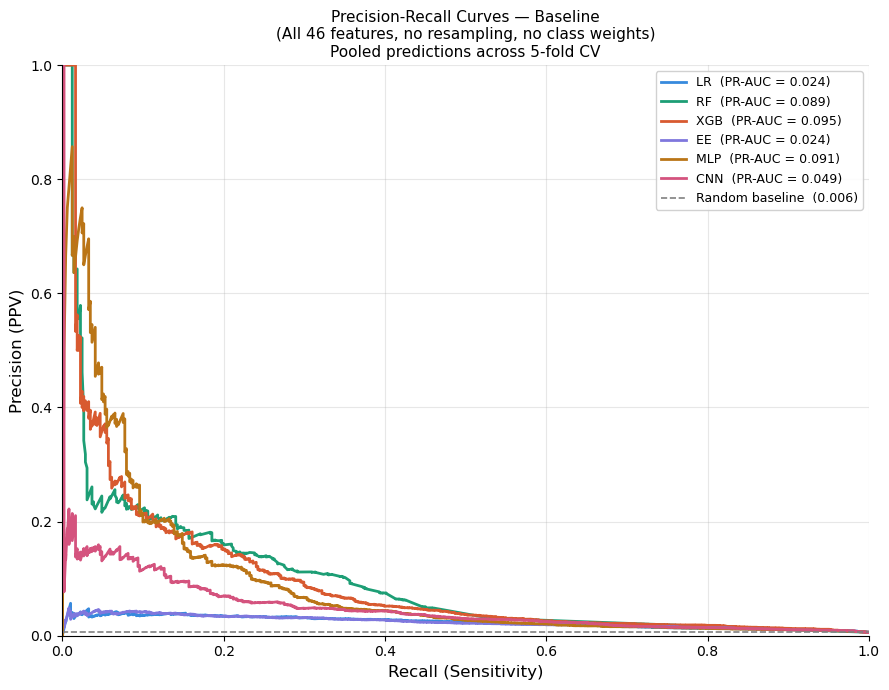


Saved: baseline_pr_curve.png


In [30]:
# ══════════════════════════════════════════════════════
# BLOCK 3: BASELINE COMPARISON — All Features, No Resampling, No Class Weights
# ══════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (classification_report,
                             average_precision_score,
                             roc_auc_score,
                             precision_recall_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from imblearn.ensemble import EasyEnsembleClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, Flatten, Dense)
from sklearn.model_selection import train_test_split as tts
import warnings
warnings.filterwarnings('ignore')
import scipy.sparse as sp

# ── Helper for metrics ────────────────────────────────
def fold_metrics(name, fold, y_true, y_pred, y_prob):
    report = classification_report(
        y_true, y_pred,
        target_names=['Alive', 'Dead'],
        output_dict=True, zero_division=0)
    pr_auc  = average_precision_score(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)
    m = {
        'Fold':      fold + 1,
        'Recall':    round(report['Dead']['recall'],    4),
        'Precision': round(report['Dead']['precision'], 4),
        'F1':        round(report['Dead']['f1-score'],  4),
        'PR-AUC':    round(pr_auc,  4),
        'ROC-AUC':   round(roc_auc, 4)
    }
    print(f"  Fold {fold+1} | {name} | "
          f"Recall={m['Recall']:.4f} | "
          f"Precision={m['Precision']:.4f} | "
          f"F1={m['F1']:.4f} | "
          f"PR-AUC={m['PR-AUC']:.4f}")
    return m

# ── Setup ─────────────────────────────────────────────
X_all = (X_processed.toarray()
         if sp.issparse(X_processed)
         else np.array(X_processed))
y_all = np.array(y)
skf   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

MODELS       = ['LR', 'RF', 'XGB', 'EE', 'MLP', 'CNN']
MODEL_COLORS = {
    'LR' : '#378ADD',
    'RF' : '#1D9E75',
    'XGB': '#D85A30',
    'EE' : '#7F77DD',
    'MLP': '#BA7517',
    'CNN': '#D4537E'
}

baseline_results = {m: [] for m in MODELS}

# Store all fold probabilities for PR curve
# shape per model: list of (y_true, y_prob) per fold
all_probs = {m: {'y_true': [], 'y_prob': []} for m in MODELS}

# ── Main K-Fold Loop ──────────────────────────────────
for fold, (train_idx, test_idx) in enumerate(
        skf.split(X_all, y_all)):

    X_tr, X_te = X_all[train_idx], X_all[test_idx]
    y_tr, y_te = y_all[train_idx], y_all[test_idx]

    # 1. LR
    lr   = LogisticRegression(
        max_iter=1000, random_state=42).fit(X_tr, y_tr)
    prob = lr.predict_proba(X_te)[:, 1]
    baseline_results['LR'].append(
        fold_metrics('LR', fold, y_te, lr.predict(X_te), prob))
    all_probs['LR']['y_true'].extend(y_te)
    all_probs['LR']['y_prob'].extend(prob)

    # 2. RF
    rf   = RandomForestClassifier(
        random_state=42, n_jobs=-1).fit(X_tr, y_tr)
    prob = rf.predict_proba(X_te)[:, 1]
    baseline_results['RF'].append(
        fold_metrics('RF', fold, y_te, rf.predict(X_te), prob))
    all_probs['RF']['y_true'].extend(y_te)
    all_probs['RF']['y_prob'].extend(prob)

    # 3. XGB
    xgb  = XGBClassifier(
        eval_metric='logloss',
        random_state=42, n_jobs=-1).fit(X_tr, y_tr)
    prob = xgb.predict_proba(X_te)[:, 1]
    baseline_results['XGB'].append(
        fold_metrics('XGB', fold, y_te, xgb.predict(X_te), prob))
    all_probs['XGB']['y_true'].extend(y_te)
    all_probs['XGB']['y_prob'].extend(prob)

    # 4. EE
    ee   = EasyEnsembleClassifier(
        random_state=42, n_jobs=-1).fit(X_tr, y_tr)
    prob = ee.predict_proba(X_te)[:, 1]
    baseline_results['EE'].append(
        fold_metrics('EE', fold, y_te, ee.predict(X_te), prob))
    all_probs['EE']['y_true'].extend(y_te)
    all_probs['EE']['y_prob'].extend(prob)

    # 5. MLP
    mlp  = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=500, random_state=42).fit(X_tr, y_tr)
    prob = mlp.predict_proba(X_te)[:, 1]
    baseline_results['MLP'].append(
        fold_metrics('MLP', fold, y_te, mlp.predict(X_te), prob))
    all_probs['MLP']['y_true'].extend(y_te)
    all_probs['MLP']['y_prob'].extend(prob)

    # 6. CNN
    n_f  = X_tr.shape[1]
    cnn  = Sequential([
        Conv1D(32, 3, activation='relu',
               input_shape=(n_f, 1)),
        Flatten(),
        Dense(32, activation='relu'),
        Dense(1,  activation='sigmoid')
    ])
    cnn.compile(optimizer='adam', loss='binary_crossentropy')
    cnn.fit(X_tr.reshape(X_tr.shape[0], n_f, 1),
            y_tr, epochs=20, verbose=0)
    prob = cnn.predict(
        X_te.reshape(X_te.shape[0], n_f, 1),
        verbose=0).flatten()
    baseline_results['CNN'].append(
        fold_metrics('CNN', fold, y_te,
                     (prob > 0.5).astype(int), prob))
    all_probs['CNN']['y_true'].extend(y_te)
    all_probs['CNN']['y_prob'].extend(prob)

# ══════════════════════════════════════════════════════
# SUMMARY TABLE
# ══════════════════════════════════════════════════════
print(f"\n{'═'*60}")
print("  FINAL SUMMARY — Mean ± Std (5-Fold CV, Baseline)")
print(f"{'═'*60}")

summary_rows = []
for model, folds in baseline_results.items():
    df  = pd.DataFrame(folds)
    row = {'Model': model}
    for metric in ['Recall','Precision','F1','PR-AUC','ROC-AUC']:
        mean = df[metric].mean()
        std  = df[metric].std()
        row[metric] = f"{mean:.4f} ± {std:.4f}"
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Model')
print(summary_df.to_string())

print(f"\n{'='*60}")
print("  BASELINE SUMMARY (All Features, No Sampling)")
print(f"{'='*60}")

summary_data = []
for model, folds in baseline_results.items():
    df = pd.DataFrame(folds)
    summary_data.append({
        'Model': model,
        **{m: round(df[m].mean(), 4)
           for m in ['Recall','Precision','F1','PR-AUC','ROC-AUC']}
    })

numeric_df = (pd.DataFrame(summary_data)
              .set_index('Model')
              .sort_values('PR-AUC', ascending=False))
print(numeric_df.to_string())

# ══════════════════════════════════════════════════════
# PRECISION-RECALL CURVE — all 6 models in one plot
# Uses pooled predictions across all 5 folds
# ══════════════════════════════════════════════════════
# Compute baseline (random classifier) = minority prevalence
baseline_rate = y_all.sum() / len(y_all)

fig, ax = plt.subplots(figsize=(9, 7))

for model in MODELS:
    y_true = np.array(all_probs[model]['y_true'])
    y_prob = np.array(all_probs[model]['y_prob'])

    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    pr_auc       = average_precision_score(y_true, y_prob)

    ax.plot(rec, prec,
            color=MODEL_COLORS[model],
            linewidth=2,
            label=f'{model}  (PR-AUC = {pr_auc:.3f})')

# Baseline: random classifier
ax.axhline(y=baseline_rate,
           color='gray', linestyle='--', linewidth=1.2,
           label=f'Random baseline  ({baseline_rate:.3f})')

ax.set_xlabel('Recall (Sensitivity)', fontsize=12)
ax.set_ylabel('Precision (PPV)', fontsize=12)
ax.set_title('Precision-Recall Curves — Baseline\n'
             '(All 46 features, no resampling, no class weights)\n'
             'Pooled predictions across 5-fold CV',
             fontsize=11)
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.spines[['top','right']].set_visible(False)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: baseline_pr_curve.png")

RF fitted for SHAP.
Computing SHAP values (may take 1-2 mins)...

SHAP Bar Plot — Dead class:


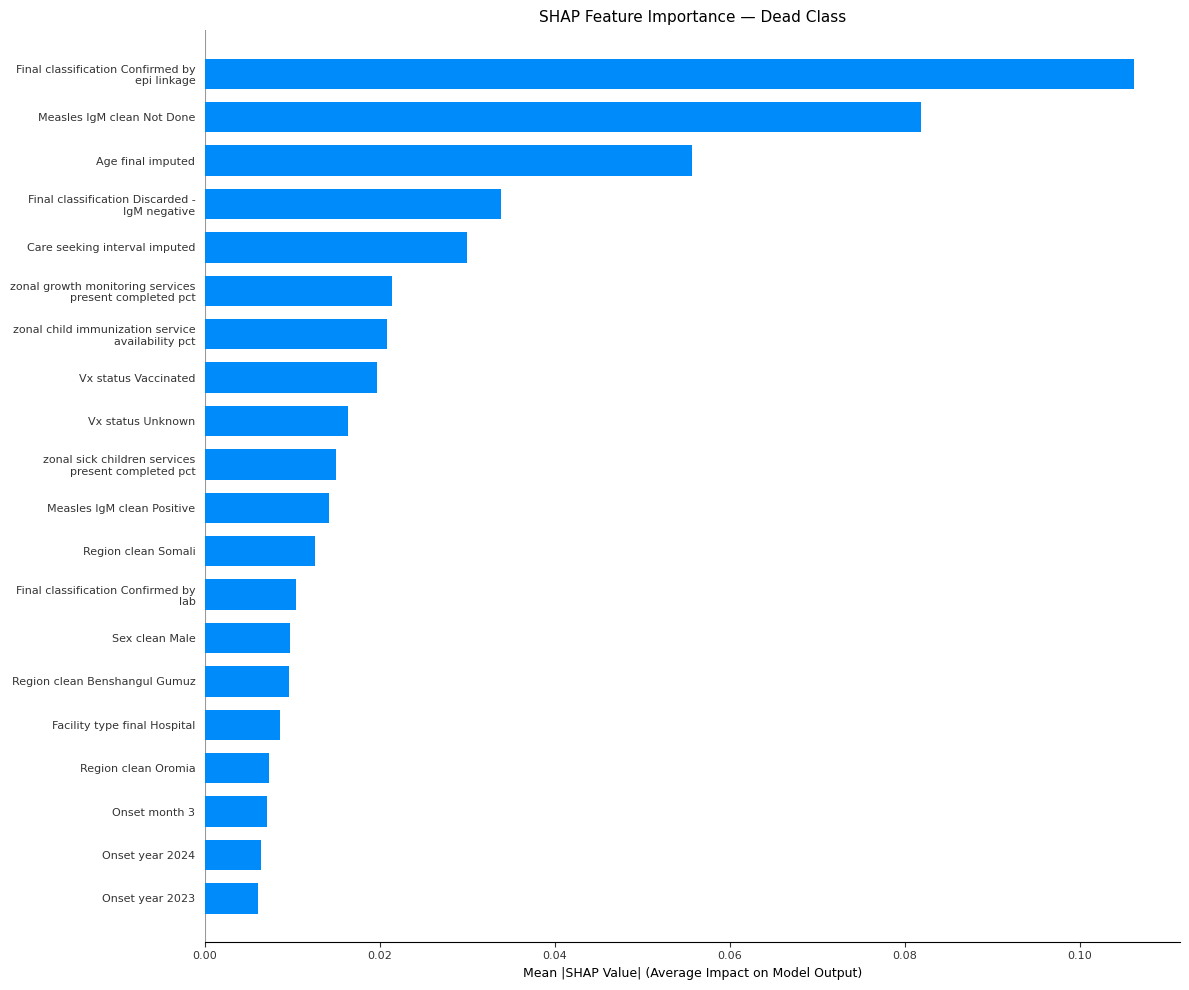


SHAP Beeswarm Plot — Dead class:


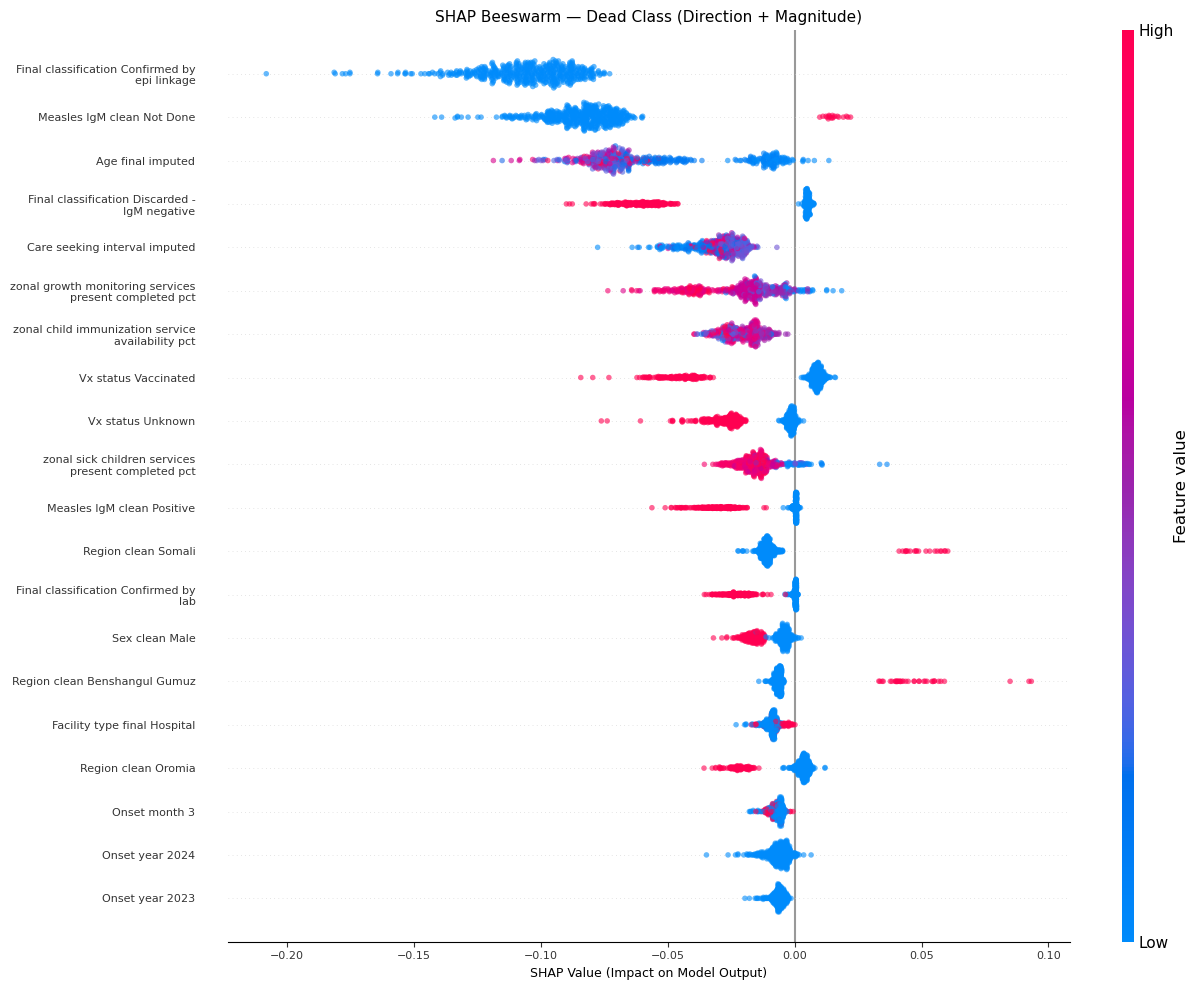


Top 20 features by SHAP importance (Dead class):
cat__Final_classification_Confirmed by epi linkage                        0.1062
cat__Measles_IgM_clean_Not Done                                           0.0819
num__Age_final_imputed                                                    0.0557
cat__Final_classification_Discarded - IgM negative                        0.0339
num__Care_seeking_interval_imputed                                        0.0300
num__aggregated_zonal_growth_monitoring_services_present_completed_pct    0.0214
num__aggregated_zonal_child_immunization_service_availability_pct         0.0208
cat__Vx_status_Vaccinated                                                 0.0197
cat__Vx_status_Unknown                                                    0.0164
num__aggregated_zonal_sick_children_services_present_completed_pct        0.0149
cat__Measles_IgM_clean_Positive                                           0.0142
cat__Region_clean_Somali                                   

In [31]:
# ══════════════════════════════════════════════════════
# BLOCK 4 — SHAP FEATURE SELECTION (full dataset)
# ══════════════════════════════════════════════════════
import numpy as np
import scipy.sparse as sp
import shap
import matplotlib.pyplot as plt
import textwrap
from sklearn.ensemble import RandomForestClassifier

# ── Quick RF on full data just for SHAP ───────────────
# This is NOT for evaluation — only for feature ranking
rf_shap = RandomForestClassifier(
    n_estimators=100,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_shap.fit(X_all, y_all)
print("RF fitted for SHAP.")

# ── Compute SHAP values ───────────────────────────────
print("Computing SHAP values (may take 1-2 mins)...")
explainer   = shap.TreeExplainer(rf_shap)
sample_size = min(500, X_all.shape[0])
shap_values = explainer.shap_values(X_all[:sample_size])

# For RF: [class0, class1] — we want class1 = Dead
shap_dead = shap_values[1] if isinstance(shap_values, list) \
            else shap_values

# ── Clean + wrap feature names for display ────────────
def wrap_name(name, width=35):
    name = name.replace('cat__', '').replace('num__', '')
    name = name.replace('aggregated_zonal_', 'zonal_')
    name = name.replace('_', ' ')
    return '\n'.join(textwrap.wrap(name, width=width))

display_names_all = [wrap_name(n) for n in feature_names]

# ── SHAP Bar Plot ─────────────────────────────────────
print("\nSHAP Bar Plot — Dead class:")
fig, ax = plt.subplots(figsize=(12, 10))
shap.summary_plot(
    shap_dead,
    X_all[:sample_size],
    feature_names=display_names_all,
    plot_type='bar',
    max_display=20,
    show=False,
    plot_size=None
)
ax = plt.gca()
ax.tick_params(axis='y', labelsize=8)
ax.tick_params(axis='x', labelsize=8)
plt.title('SHAP Feature Importance — Dead Class', fontsize=11)
plt.xlabel('Mean |SHAP Value| (Average Impact on Model Output)',
           fontsize=9)
plt.tight_layout()
plt.savefig('shap_bar_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# ── SHAP Beeswarm Plot ────────────────────────────────
print("\nSHAP Beeswarm Plot — Dead class:")
fig, ax = plt.subplots(figsize=(13, 10))
shap.summary_plot(
    shap_dead,
    X_all[:sample_size],
    feature_names=display_names_all,
    max_display=20,
    show=False,
    plot_size=None,
    alpha=0.6
)
ax = plt.gca()
ax.tick_params(axis='y', labelsize=8)
ax.tick_params(axis='x', labelsize=8)
plt.title('SHAP Beeswarm — Dead Class (Direction + Magnitude)',
          fontsize=11)
plt.xlabel('SHAP Value (Impact on Model Output)', fontsize=9)
plt.tight_layout()
plt.savefig('shap_beeswarm_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Extract importance scores ─────────────────────────
shap_importance = pd.Series(
    np.abs(shap_dead).mean(axis=0),
    index=feature_names          # keep original names for indexing
).sort_values(ascending=False)

print("\nTop 20 features by SHAP importance (Dead class):")
print(shap_importance.head(20).round(4).to_string())

# ── Select top 20 ─────────────────────────────────────
shap_top20_names = shap_importance.head(20).index.tolist()
shap_top20_idx   = [list(feature_names).index(f)
                    for f in shap_top20_names]

# Wrapped versions of top 20 names (for use in later plots)
shap_top20_display = [wrap_name(n) for n in shap_top20_names]

print(f"\nSelected feature indices: {shap_top20_idx}")
print(f"\nSelected feature names:")
for i, (orig, disp) in enumerate(
        zip(shap_top20_names, shap_top20_display), 1):
    print(f"  {i:2d}. {disp.replace(chr(10), ' | ')}")

# ── Slice full dataset ────────────────────────────────
X_sel  = X_all[:, shap_top20_idx]
n_feat = len(shap_top20_idx)    # 20

print(f"\nDataset after feature selection : {X_sel.shape}")
print(f"Class distribution — Alive: {(y_all==0).sum()} "
      f"| Dead: {(y_all==1).sum()}")

X_sel shape : (83436, 20)
y_all shape : (83436,)
n_feat      : 20
Dead cases  : 491
Alive cases : 82945

Features used (top 20 by SHAP):
   1. Final classification Confirmed by | epi linkage
   2. Measles IgM clean Not Done
   3. Age final imputed
   4. Final classification Discarded - | IgM negative
   5. Care seeking interval imputed
   6. zonal growth monitoring services | present completed pct
   7. zonal child immunization service | availability pct
   8. Vx status Vaccinated
   9. Vx status Unknown
  10. zonal sick children services | present completed pct
  11. Measles IgM clean Positive
  12. Region clean Somali
  13. Final classification Confirmed by | lab
  14. Sex clean Male
  15. Region clean Benshangul Gumuz
  16. Facility type final Hospital
  17. Region clean Oromia
  18. Onset month 3
  19. Onset year 2024
  20. Onset year 2023

════════════════════════════════════════════════════════════
  FOLD 1 / 5
════════════════════════════════════════════════════════════
  Train 

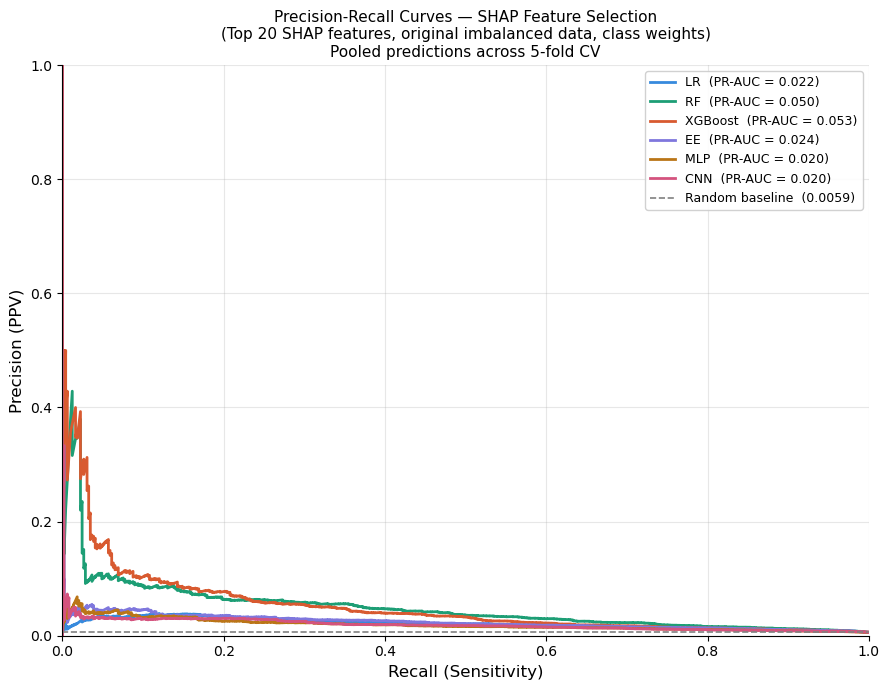

Saved: shap_noresample_pr_curve.png


In [32]:
# ══════════════════════════════════════════════════════
# BLOCK 5 — With feature selection using SHAP (only 20 features,
# originally they were 46) (no resampling or tuning, but with class weight)
# All models: LR, RF, XGB, EasyEnsemble, MLP, 1D-CNN
# + PRECISION-RECALL CURVE at the end
# ══════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (classification_report,
                             average_precision_score,
                             roc_auc_score,
                             precision_recall_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from imblearn.ensemble import EasyEnsembleClassifier
from sklearn.utils import class_weight as cw
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Flatten,
                                     Dense, Dropout, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split as tts
import warnings
warnings.filterwarnings('ignore')

# ── Confirm inputs from Block 4 ───────────────────────
print(f"X_sel shape : {X_sel.shape}")
print(f"y_all shape : {y_all.shape}")
print(f"n_feat      : {n_feat}")
print(f"Dead cases  : {(y_all==1).sum()}")
print(f"Alive cases : {(y_all==0).sum()}")
print(f"\nFeatures used (top 20 by SHAP):")
for i, name in enumerate(shap_top20_display, 1):
    print(f"  {i:2d}. {name.replace(chr(10), ' | ')}")

# ── Color map ─────────────────────────────────────────
MODEL_COLORS = {
    'Logistic Regression': '#378ADD',
    'Random Forest':       '#1D9E75',
    'XGBoost':             '#D85A30',
    'EasyEnsemble':        '#7F77DD',
    'MLP':                 '#BA7517',
    '1D-CNN':              '#D4537E'
}

# ── K-Fold setup ──────────────────────────────────────
N_SPLITS = 5
skf      = StratifiedKFold(n_splits=N_SPLITS,
                            shuffle=True, random_state=42)

fold_results = {m: [] for m in MODEL_COLORS}

# ── Storage for PR curve (pooled across all folds) ────
all_probs = {m: {'y_true': [], 'y_prob': []}
             for m in MODEL_COLORS}

# ── Metrics helper ────────────────────────────────────
def fold_metrics(name, fold, y_true, y_pred, y_prob):
    report  = classification_report(
        y_true, y_pred,
        target_names=['Alive', 'Dead'],
        output_dict=True, zero_division=0)
    pr_auc  = average_precision_score(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)
    m = {
        'Fold':      fold + 1,
        'Recall':    round(report['Dead']['recall'],    4),
        'Precision': round(report['Dead']['precision'], 4),
        'F1':        round(report['Dead']['f1-score'],  4),
        'PR-AUC':    round(pr_auc,  4),
        'ROC-AUC':   round(roc_auc, 4)
    }
    print(f"   Fold {fold+1} | "
          f"Recall={m['Recall']:.4f}  "
          f"Precision={m['Precision']:.4f}  "
          f"F1={m['F1']:.4f}  "
          f"PR-AUC={m['PR-AUC']:.4f}  "
          f"ROC-AUC={m['ROC-AUC']:.4f}")
    return m

# ══════════════════════════════════════════════════════
# MAIN K-FOLD LOOP
# ══════════════════════════════════════════════════════
for fold, (train_idx, test_idx) in enumerate(
        skf.split(X_sel, y_all)):

    print(f"\n{'═'*60}")
    print(f"  FOLD {fold+1} / {N_SPLITS}")
    print(f"{'═'*60}")

    X_tr_raw = X_sel[train_idx]
    X_te     = X_sel[test_idx]
    y_tr_raw = y_all[train_idx]
    y_te     = y_all[test_idx]

    print(f"  Train : {X_tr_raw.shape} | "
          f"Dead={y_tr_raw.sum()}  "
          f"Alive={(y_tr_raw==0).sum()}")
    print(f"  Test  : {X_te.shape}  | "
          f"Dead={y_te.sum()}  "
          f"Alive={(y_te==0).sum()}")

    # ── No resampling, use class weights ──────────────
    X_tr_sm, y_tr_sm = X_tr_raw, y_tr_raw
    print(f"  Using Original Data")

    weights = cw.compute_class_weight(
        'balanced', classes=np.unique(y_tr_sm), y=y_tr_sm)
    cw_dict = dict(enumerate(weights))
    spw     = weights[1] / weights[0]

    # ── 1. Logistic Regression ────────────────────────
    print("\n  [LR]")
    lr   = LogisticRegression(
        max_iter=1000, random_state=42,
        solver='lbfgs', class_weight='balanced')
    lr.fit(X_tr_sm, y_tr_sm)
    prob = lr.predict_proba(X_te)[:, 1]
    fold_results['Logistic Regression'].append(
        fold_metrics('LR', fold, y_te, lr.predict(X_te), prob))
    all_probs['Logistic Regression']['y_true'].extend(y_te)
    all_probs['Logistic Regression']['y_prob'].extend(prob)

    # ── 2. Random Forest ──────────────────────────────
    print("\n  [RF]")
    rf   = RandomForestClassifier(
        n_estimators=200, min_samples_leaf=5,
        class_weight='balanced', random_state=42, n_jobs=-1)
    rf.fit(X_tr_sm, y_tr_sm)
    prob = rf.predict_proba(X_te)[:, 1]
    fold_results['Random Forest'].append(
        fold_metrics('RF', fold, y_te, rf.predict(X_te), prob))
    all_probs['Random Forest']['y_true'].extend(y_te)
    all_probs['Random Forest']['y_prob'].extend(prob)

    # ── 3. XGBoost ────────────────────────────────────
    print("\n  [XGB]")
    xgb  = XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=spw, eval_metric='logloss',
        use_label_encoder=False, random_state=42, n_jobs=-1)
    xgb.fit(X_tr_sm, y_tr_sm,
            eval_set=[(X_te, y_te)], verbose=False)
    prob = xgb.predict_proba(X_te)[:, 1]
    fold_results['XGBoost'].append(
        fold_metrics('XGB', fold, y_te, xgb.predict(X_te), prob))
    all_probs['XGBoost']['y_true'].extend(y_te)
    all_probs['XGBoost']['y_prob'].extend(prob)

    # ── 4. EasyEnsemble (raw data — no SMOTE) ─────────
    print("\n  [EasyEnsemble]")
    ee   = EasyEnsembleClassifier(
        n_estimators=20, random_state=42, n_jobs=-1)
    ee.fit(X_tr_raw, y_tr_raw)
    prob = ee.predict_proba(X_te)[:, 1]
    fold_results['EasyEnsemble'].append(
        fold_metrics('EE', fold, y_te, ee.predict(X_te), prob))
    all_probs['EasyEnsemble']['y_true'].extend(y_te)
    all_probs['EasyEnsemble']['y_prob'].extend(prob)

    # ── 5. MLP ────────────────────────────────────────
    print("\n  [MLP]")
    mlp  = MLPClassifier(
        hidden_layer_sizes=(128, 64, 32), activation='relu',
        solver='adam', alpha=0.001, learning_rate='adaptive',
        max_iter=500, early_stopping=True,
        validation_fraction=0.1, random_state=42)
    mlp.fit(X_tr_sm, y_tr_sm)
    prob = mlp.predict_proba(X_te)[:, 1]
    fold_results['MLP'].append(
        fold_metrics('MLP', fold, y_te, mlp.predict(X_te), prob))
    all_probs['MLP']['y_true'].extend(y_te)
    all_probs['MLP']['y_prob'].extend(prob)

    # ── 6. 1D-CNN ─────────────────────────────────────
    print("\n  [1D-CNN]")
    X_c_tr, X_c_val, y_c_tr, y_c_val = tts(
        X_tr_sm, y_tr_sm, test_size=0.15,
        stratify=y_tr_sm, random_state=42)

    X_c_tr  = X_c_tr.reshape( X_c_tr.shape[0],  n_feat, 1)
    X_c_val = X_c_val.reshape(X_c_val.shape[0], n_feat, 1)
    X_c_te  = X_te.reshape(   X_te.shape[0],    n_feat, 1)

    tf.keras.backend.clear_session()
    cnn = Sequential([
        Conv1D(64,  kernel_size=3, activation='relu',
               input_shape=(n_feat, 1)),
        BatchNormalization(), MaxPooling1D(pool_size=2),
        Conv1D(128, kernel_size=3, activation='relu'),
        BatchNormalization(), MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(64, activation='relu'), Dropout(0.4),
        Dense(32, activation='relu'), Dropout(0.3),
        Dense(1,  activation='sigmoid')
    ])
    cnn.compile(
        optimizer=tf.keras.optimizers.Adam(0.0005),
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='auc', curve='PR')
        ]
    )
    cnn.fit(
        X_c_tr, y_c_tr,
        epochs=100, batch_size=128,
        validation_data=(X_c_val, y_c_val),
        class_weight=cw_dict,
        callbacks=[EarlyStopping(
            monitor='val_auc', patience=15,
            restore_best_weights=True, mode='max')],
        verbose=0
    )
    prob       = cnn.predict(X_c_te, verbose=0).flatten()
    y_pred_cnn = (prob >= 0.5).astype(int)
    fold_results['1D-CNN'].append(
        fold_metrics('CNN', fold, y_te, y_pred_cnn, prob))
    all_probs['1D-CNN']['y_true'].extend(y_te)
    all_probs['1D-CNN']['y_prob'].extend(prob)

# ══════════════════════════════════════════════════════
# SUMMARY TABLE
# ══════════════════════════════════════════════════════
print(f"\n{'═'*60}")
print("  FINAL SUMMARY — Mean ± Std (5-Fold CV, Default Params)")
print(f"{'═'*60}")

summary_rows = []
for model_name, folds in fold_results.items():
    df  = pd.DataFrame(folds)
    row = {'Model': model_name}
    for metric in ['Recall', 'Precision', 'F1', 'PR-AUC', 'ROC-AUC']:
        mean = df[metric].mean()
        std  = df[metric].std()
        row[metric] = f"{mean:.4f} ± {std:.4f}"
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Model')
print(summary_df.to_string())

print(f"\n{'═'*60}")
print("  MEAN ONLY — sorted by PR-AUC")
print(f"{'═'*60}")

numeric_rows = []
for model_name, folds in fold_results.items():
    df  = pd.DataFrame(folds)
    row = {'Model': model_name}
    for metric in ['Recall', 'Precision', 'F1', 'PR-AUC', 'ROC-AUC']:
        row[metric] = round(df[metric].mean(), 4)
    numeric_rows.append(row)

numeric_df = (pd.DataFrame(numeric_rows)
              .set_index('Model')
              .sort_values('PR-AUC', ascending=False))
print(numeric_df.to_string())

numeric_df.to_csv('kfold_default_results.csv')
print("\nSaved: kfold_default_results.csv")

# ══════════════════════════════════════════════════════
# PRECISION-RECALL CURVE — all 6 models in one plot
# Pooled predictions across all 5 folds
# ══════════════════════════════════════════════════════
baseline_rate = y_all.sum() / len(y_all)

fig, ax = plt.subplots(figsize=(9, 7))

for model_name in MODEL_COLORS:
    y_true = np.array(all_probs[model_name]['y_true'])
    y_prob = np.array(all_probs[model_name]['y_prob'])

    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    pr_auc       = average_precision_score(y_true, y_prob)

    short = (model_name
             .replace('Logistic Regression', 'LR')
             .replace('Random Forest', 'RF')
             .replace('EasyEnsemble', 'EE')
             .replace('1D-CNN', 'CNN'))

    ax.plot(rec, prec,
            color=MODEL_COLORS[model_name],
            linewidth=2,
            label=f'{short}  (PR-AUC = {pr_auc:.3f})')

ax.axhline(y=baseline_rate,
           color='gray', linestyle='--', linewidth=1.2,
           label=f'Random baseline  ({baseline_rate:.4f})')

ax.set_xlabel('Recall (Sensitivity)', fontsize=12)
ax.set_ylabel('Precision (PPV)', fontsize=12)
ax.set_title(
    'Precision-Recall Curves — SHAP Feature Selection\n'
    '(Top 20 SHAP features, original imbalanced data, class weights)\n'
    'Pooled predictions across 5-fold CV',
    fontsize=11)
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('shap_noresample_pr_curve.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("Saved: shap_noresample_pr_curve.png")

   1. Final classification Confirmed by | epi linkage
   2. Measles IgM clean Not Done
   3. Age final imputed
   4. Final classification Discarded - | IgM negative
   5. Care seeking interval imputed
   6. zonal growth monitoring services | present completed pct
   7. zonal child immunization service | availability pct
   8. Vx status Vaccinated
   9. Vx status Unknown
  10. zonal sick children services | present completed pct
  11. Measles IgM clean Positive
  12. Region clean Somali
  13. Final classification Confirmed by | lab
  14. Sex clean Male
  15. Region clean Benshangul Gumuz
  16. Facility type final Hospital
  17. Region clean Oromia
  18. Onset month 3
  19. Onset year 2024
  20. Onset year 2023



════════════════════════════════════════════════════════════
  FOLD 1 / 5
════════════════════════════════════════════════════════════
  Train : (66748, 20) | Dead=392  Alive=66356
  Test  : (16688, 20)  | Dead=99  Alive=16589
  Undersampling: (1176, 20)

  [LR]
   Fold 1 | Recall=0.7475  Precision=0.0148  F1=0.0291  PR-AUC=0.0198  ROC-AUC=0.7838

  [RF]
   Fold 1 | Recall=0.6970  Precision=0.0183  F1=0.0357  PR-AUC=0.0238  ROC-AUC=0.8196

  [XGB]
   Fold 1 | Recall=0.6364  Precision=0.0190  F1=0.0369  PR-AUC=0.0249  ROC-AUC=0.8053

  [EasyEnsemble]
   Fold 1 | Recall=0.8081  Precision=0.0145  F1=0.0285  PR-AUC=0.0244  ROC-AUC=0.7995

  [MLP]
   Fold 1 | Recall=0.3636  Precision=0.0204  F1=0.0386  PR-AUC=0.0205  ROC-AUC=0.7527

  [1D-CNN]
   Fold 1 | Recall=0.6768  Precision=0.0150  F1=0.0293  PR-AUC=0.0253  ROC-AUC=0.7783

════════════════════════════════════════════════════════════
  FOLD 2 / 5
════════════════════════════════════════════════════════════
  Train : (66749, 20) | Dead

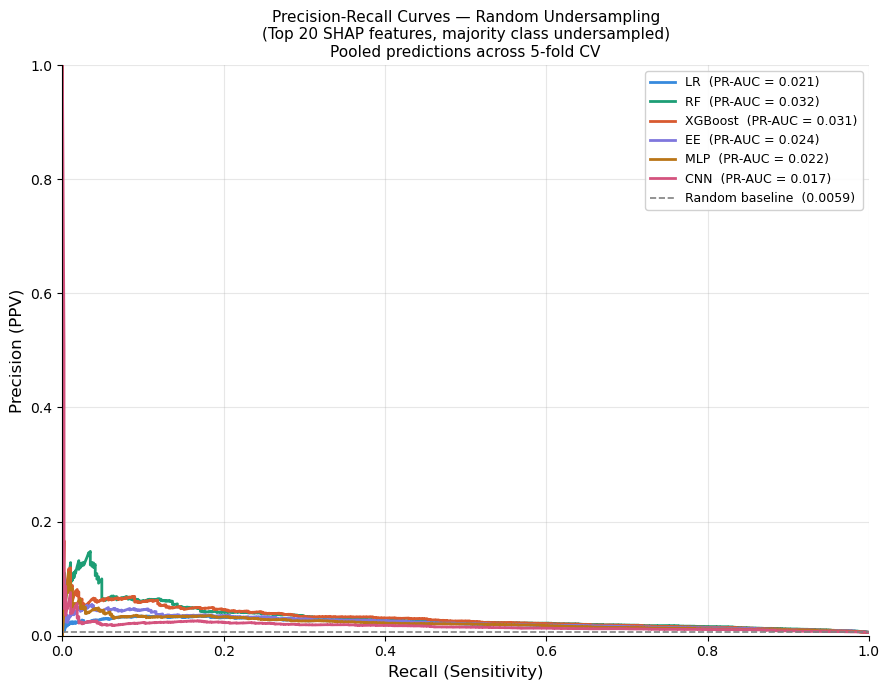

Saved: undersample_pr_curve.png


In [33]:
# ══════════════════════════════════════════════════════
# BLOCK 6 — K-FOLD CV, Method 2: Random Undersampling
# All models: LR, RF, XGB, EasyEnsemble, MLP, 1D-CNN
# + PRECISION-RECALL CURVE at the end
# ══════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (classification_report,
                             average_precision_score,
                             roc_auc_score,
                             precision_recall_curve)
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from imblearn.ensemble import EasyEnsembleClassifier
from sklearn.utils import class_weight as cw
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Flatten,
                                     Dense, Dropout, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split as tts
import warnings
warnings.filterwarnings('ignore')

for i, name in enumerate(shap_top20_display, 1):
    print(f"  {i:2d}. {name.replace(chr(10), ' | ')}")

# ── Color map ─────────────────────────────────────────
MODEL_COLORS = {
    'Logistic Regression': '#378ADD',
    'Random Forest':       '#1D9E75',
    'XGBoost':             '#D85A30',
    'EasyEnsemble':        '#7F77DD',
    'MLP':                 '#BA7517',
    '1D-CNN':              '#D4537E'
}

# ── K-Fold setup ──────────────────────────────────────
N_SPLITS = 5
skf      = StratifiedKFold(n_splits=N_SPLITS,
                            shuffle=True, random_state=42)

fold_results = {m: [] for m in MODEL_COLORS}

# ── Storage for PR curve (pooled across all folds) ────
all_probs = {m: {'y_true': [], 'y_prob': []}
             for m in MODEL_COLORS}

# ── Metrics helper ────────────────────────────────────
def fold_metrics(name, fold, y_true, y_pred, y_prob):
    report  = classification_report(
        y_true, y_pred,
        target_names=['Alive', 'Dead'],
        output_dict=True, zero_division=0)
    pr_auc  = average_precision_score(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)
    m = {
        'Fold':      fold + 1,
        'Recall':    round(report['Dead']['recall'],    4),
        'Precision': round(report['Dead']['precision'], 4),
        'F1':        round(report['Dead']['f1-score'],  4),
        'PR-AUC':    round(pr_auc,  4),
        'ROC-AUC':   round(roc_auc, 4)
    }
    print(f"   Fold {fold+1} | "
          f"Recall={m['Recall']:.4f}  "
          f"Precision={m['Precision']:.4f}  "
          f"F1={m['F1']:.4f}  "
          f"PR-AUC={m['PR-AUC']:.4f}  "
          f"ROC-AUC={m['ROC-AUC']:.4f}")
    return m

# ══════════════════════════════════════════════════════
# MAIN K-FOLD LOOP
# ══════════════════════════════════════════════════════
for fold, (train_idx, test_idx) in enumerate(
        skf.split(X_sel, y_all)):

    print(f"\n{'═'*60}")
    print(f"  FOLD {fold+1} / {N_SPLITS}")
    print(f"{'═'*60}")

    X_tr_raw = X_sel[train_idx]
    X_te     = X_sel[test_idx]
    y_tr_raw = y_all[train_idx]
    y_te     = y_all[test_idx]

    print(f"  Train : {X_tr_raw.shape} | "
          f"Dead={y_tr_raw.sum()}  "
          f"Alive={(y_tr_raw==0).sum()}")
    print(f"  Test  : {X_te.shape}  | "
          f"Dead={y_te.sum()}  "
          f"Alive={(y_te==0).sum()}")

    # ── Random Undersampling ──────────────────────────
    rus = RandomUnderSampler(sampling_strategy=0.5, random_state=42)
    X_tr_sm, y_tr_sm = rus.fit_resample(X_tr_raw, y_tr_raw)
    print(f"  Undersampling: {X_tr_sm.shape}")

    weights = cw.compute_class_weight(
        'balanced', classes=np.unique(y_tr_sm), y=y_tr_sm)
    cw_dict = dict(enumerate(weights))
    spw     = weights[1] / weights[0]

    # ── 1. Logistic Regression ────────────────────────
    print("\n  [LR]")
    lr   = LogisticRegression(
        max_iter=1000, random_state=42,
        solver='lbfgs', class_weight='balanced')
    lr.fit(X_tr_sm, y_tr_sm)
    prob = lr.predict_proba(X_te)[:, 1]
    fold_results['Logistic Regression'].append(
        fold_metrics('LR', fold, y_te, lr.predict(X_te), prob))
    all_probs['Logistic Regression']['y_true'].extend(y_te)
    all_probs['Logistic Regression']['y_prob'].extend(prob)

    # ── 2. Random Forest ──────────────────────────────
    print("\n  [RF]")
    rf   = RandomForestClassifier(
        n_estimators=200, min_samples_leaf=5,
        class_weight='balanced', random_state=42, n_jobs=-1)
    rf.fit(X_tr_sm, y_tr_sm)
    prob = rf.predict_proba(X_te)[:, 1]
    fold_results['Random Forest'].append(
        fold_metrics('RF', fold, y_te, rf.predict(X_te), prob))
    all_probs['Random Forest']['y_true'].extend(y_te)
    all_probs['Random Forest']['y_prob'].extend(prob)

    # ── 3. XGBoost ────────────────────────────────────
    print("\n  [XGB]")
    xgb  = XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=spw, eval_metric='logloss',
        use_label_encoder=False, random_state=42, n_jobs=-1)
    xgb.fit(X_tr_sm, y_tr_sm,
            eval_set=[(X_te, y_te)], verbose=False)
    prob = xgb.predict_proba(X_te)[:, 1]
    fold_results['XGBoost'].append(
        fold_metrics('XGB', fold, y_te, xgb.predict(X_te), prob))
    all_probs['XGBoost']['y_true'].extend(y_te)
    all_probs['XGBoost']['y_prob'].extend(prob)

    # ── 4. EasyEnsemble (raw data — no undersampling) ─
    print("\n  [EasyEnsemble]")
    ee   = EasyEnsembleClassifier(
        n_estimators=20, random_state=42, n_jobs=-1)
    ee.fit(X_tr_raw, y_tr_raw)
    prob = ee.predict_proba(X_te)[:, 1]
    fold_results['EasyEnsemble'].append(
        fold_metrics('EE', fold, y_te, ee.predict(X_te), prob))
    all_probs['EasyEnsemble']['y_true'].extend(y_te)
    all_probs['EasyEnsemble']['y_prob'].extend(prob)

    # ── 5. MLP ────────────────────────────────────────
    print("\n  [MLP]")
    mlp  = MLPClassifier(
        hidden_layer_sizes=(128, 64, 32), activation='relu',
        solver='adam', alpha=0.001, learning_rate='adaptive',
        max_iter=500, early_stopping=True,
        validation_fraction=0.1, random_state=42)
    mlp.fit(X_tr_sm, y_tr_sm)
    prob = mlp.predict_proba(X_te)[:, 1]
    fold_results['MLP'].append(
        fold_metrics('MLP', fold, y_te, mlp.predict(X_te), prob))
    all_probs['MLP']['y_true'].extend(y_te)
    all_probs['MLP']['y_prob'].extend(prob)

    # ── 6. 1D-CNN ─────────────────────────────────────
    print("\n  [1D-CNN]")
    X_c_tr, X_c_val, y_c_tr, y_c_val = tts(
        X_tr_sm, y_tr_sm, test_size=0.15,
        stratify=y_tr_sm, random_state=42)

    X_c_tr  = X_c_tr.reshape( X_c_tr.shape[0],  n_feat, 1)
    X_c_val = X_c_val.reshape(X_c_val.shape[0], n_feat, 1)
    X_c_te  = X_te.reshape(   X_te.shape[0],    n_feat, 1)

    tf.keras.backend.clear_session()
    cnn = Sequential([
        Conv1D(64,  kernel_size=3, activation='relu',
               input_shape=(n_feat, 1)),
        BatchNormalization(), MaxPooling1D(pool_size=2),
        Conv1D(128, kernel_size=3, activation='relu'),
        BatchNormalization(), MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(64, activation='relu'), Dropout(0.4),
        Dense(32, activation='relu'), Dropout(0.3),
        Dense(1,  activation='sigmoid')
    ])
    cnn.compile(
        optimizer=tf.keras.optimizers.Adam(0.0005),
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='auc', curve='PR')
        ]
    )
    cnn.fit(
        X_c_tr, y_c_tr,
        epochs=100, batch_size=128,
        validation_data=(X_c_val, y_c_val),
        class_weight=cw_dict,
        callbacks=[EarlyStopping(
            monitor='val_auc', patience=15,
            restore_best_weights=True, mode='max')],
        verbose=0
    )
    prob       = cnn.predict(X_c_te, verbose=0).flatten()
    y_pred_cnn = (prob >= 0.5).astype(int)
    fold_results['1D-CNN'].append(
        fold_metrics('CNN', fold, y_te, y_pred_cnn, prob))
    all_probs['1D-CNN']['y_true'].extend(y_te)
    all_probs['1D-CNN']['y_prob'].extend(prob)

# ══════════════════════════════════════════════════════
# SUMMARY TABLE
# ══════════════════════════════════════════════════════
print(f"\n{'═'*60}")
print("  FINAL SUMMARY — Mean ± Std (5-Fold CV, Undersampling)")
print(f"{'═'*60}")

summary_rows = []
for model_name, folds in fold_results.items():
    df  = pd.DataFrame(folds)
    row = {'Model': model_name}
    for metric in ['Recall', 'Precision', 'F1', 'PR-AUC', 'ROC-AUC']:
        mean = df[metric].mean()
        std  = df[metric].std()
        row[metric] = f"{mean:.4f} ± {std:.4f}"
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Model')
print(summary_df.to_string())

print(f"\n{'═'*60}")
print("  MEAN ONLY — sorted by PR-AUC")
print(f"{'═'*60}")

numeric_rows = []
for model_name, folds in fold_results.items():
    df  = pd.DataFrame(folds)
    row = {'Model': model_name}
    for metric in ['Recall', 'Precision', 'F1', 'PR-AUC', 'ROC-AUC']:
        row[metric] = round(df[metric].mean(), 4)
    numeric_rows.append(row)

numeric_df = (pd.DataFrame(numeric_rows)
              .set_index('Model')
              .sort_values('PR-AUC', ascending=False))
print(numeric_df.to_string())

numeric_df.to_csv('kfold_undersample_results.csv')
print("\nSaved: kfold_undersample_results.csv")

# ══════════════════════════════════════════════════════
# PRECISION-RECALL CURVE — all 6 models in one plot
# Pooled predictions across all 5 folds
# ══════════════════════════════════════════════════════
baseline_rate = y_all.sum() / len(y_all)

fig, ax = plt.subplots(figsize=(9, 7))

for model_name in MODEL_COLORS:
    y_true = np.array(all_probs[model_name]['y_true'])
    y_prob = np.array(all_probs[model_name]['y_prob'])

    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    pr_auc       = average_precision_score(y_true, y_prob)

    short = (model_name
             .replace('Logistic Regression', 'LR')
             .replace('Random Forest', 'RF')
             .replace('EasyEnsemble', 'EE')
             .replace('1D-CNN', 'CNN'))

    ax.plot(rec, prec,
            color=MODEL_COLORS[model_name],
            linewidth=2,
            label=f'{short}  (PR-AUC = {pr_auc:.3f})')

ax.axhline(y=baseline_rate,
           color='gray', linestyle='--', linewidth=1.2,
           label=f'Random baseline  ({baseline_rate:.4f})')

ax.set_xlabel('Recall (Sensitivity)', fontsize=12)
ax.set_ylabel('Precision (PPV)', fontsize=12)
ax.set_title(
    'Precision-Recall Curves — Random Undersampling\n'
    '(Top 20 SHAP features, majority class undersampled)\n'
    'Pooled predictions across 5-fold CV',
    fontsize=11)
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('undersample_pr_curve.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("Saved: undersample_pr_curve.png")

   1. Final classification Confirmed by | epi linkage
   2. Measles IgM clean Not Done
   3. Age final imputed
   4. Final classification Discarded - | IgM negative
   5. Care seeking interval imputed
   6. zonal growth monitoring services | present completed pct
   7. zonal child immunization service | availability pct
   8. Vx status Vaccinated
   9. Vx status Unknown
  10. zonal sick children services | present completed pct
  11. Measles IgM clean Positive
  12. Region clean Somali
  13. Final classification Confirmed by | lab
  14. Sex clean Male
  15. Region clean Benshangul Gumuz
  16. Facility type final Hospital
  17. Region clean Oromia
  18. Onset month 3
  19. Onset year 2024
  20. Onset year 2023

════════════════════════════════════════════════════════════
  FOLD 1 / 5
════════════════════════════════════════════════════════════
  Train : (66748, 20) | Dead=392  Alive=66356
  Test  : (16688, 20)  | Dead=99  Alive=16589


  SMOTE: (99534, 20)

  [LR]
   Fold 1 | Recall=0.7374  Precision=0.0150  F1=0.0295  PR-AUC=0.0212  ROC-AUC=0.7800

  [RF]
   Fold 1 | Recall=0.1111  Precision=0.0748  F1=0.0894  PR-AUC=0.0463  ROC-AUC=0.8521

  [XGB]
   Fold 1 | Recall=0.0505  Precision=0.0394  F1=0.0442  PR-AUC=0.0376  ROC-AUC=0.8085

  [EasyEnsemble]
   Fold 1 | Recall=0.8081  Precision=0.0145  F1=0.0285  PR-AUC=0.0244  ROC-AUC=0.7995

  [MLP]
   Fold 1 | Recall=0.2121  Precision=0.0407  F1=0.0683  PR-AUC=0.0428  ROC-AUC=0.7643

  [1D-CNN]
   Fold 1 | Recall=0.3030  Precision=0.0337  F1=0.0606  PR-AUC=0.0271  ROC-AUC=0.7601

════════════════════════════════════════════════════════════
  FOLD 2 / 5
════════════════════════════════════════════════════════════
  Train : (66749, 20) | Dead=393  Alive=66356
  Test  : (16687, 20)  | Dead=98  Alive=16589
  SMOTE: (99534, 20)

  [LR]
   Fold 2 | Recall=0.7653  Precision=0.0149  F1=0.0292  PR-AUC=0.0314  ROC-AUC=0.8167

  [RF]
   Fold 2 | Recall=0.1122  Precision=0.0780  F1=

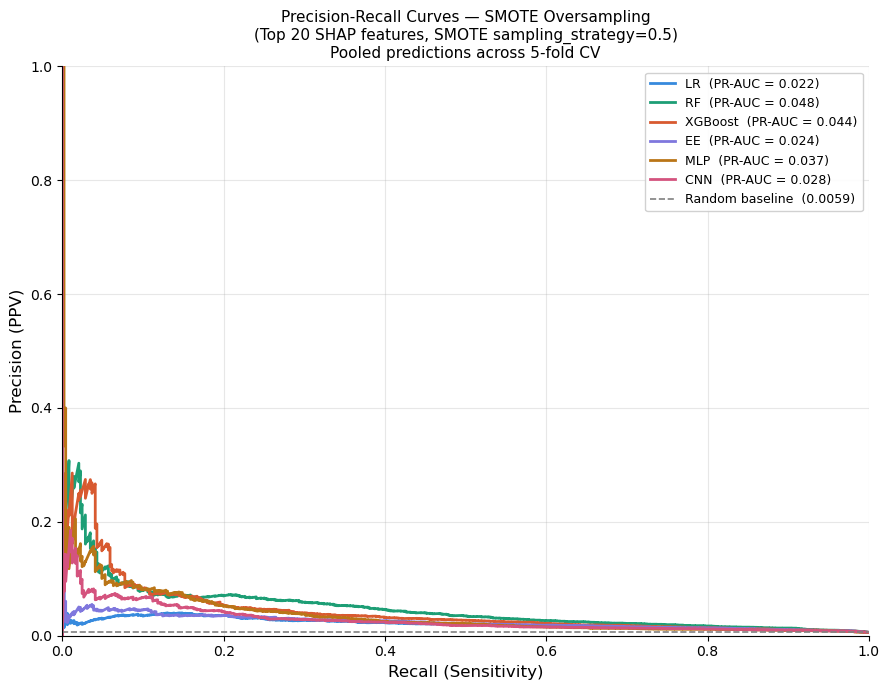

Saved: smote_pr_curve.png


In [34]:
# ══════════════════════════════════════════════════════
# BLOCK 7 — K-FOLD CV, Method 3: SMOTE Oversampling
# All models: LR, RF, XGB, EasyEnsemble, MLP, 1D-CNN
# + PRECISION-RECALL CURVE at the end
# ══════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (classification_report,
                             average_precision_score,
                             roc_auc_score,
                             precision_recall_curve)
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from imblearn.ensemble import EasyEnsembleClassifier
from sklearn.utils import class_weight as cw
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Flatten,
                                     Dense, Dropout, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split as tts
import warnings
warnings.filterwarnings('ignore')

for i, name in enumerate(shap_top20_display, 1):
    print(f"  {i:2d}. {name.replace(chr(10), ' | ')}")

# ── Color map ─────────────────────────────────────────
MODEL_COLORS = {
    'Logistic Regression': '#378ADD',
    'Random Forest':       '#1D9E75',
    'XGBoost':             '#D85A30',
    'EasyEnsemble':        '#7F77DD',
    'MLP':                 '#BA7517',
    '1D-CNN':              '#D4537E'
}

# ── K-Fold setup ──────────────────────────────────────
N_SPLITS = 5
skf      = StratifiedKFold(n_splits=N_SPLITS,
                            shuffle=True, random_state=42)

fold_results = {m: [] for m in MODEL_COLORS}

# ── Storage for PR curve (pooled across all folds) ────
all_probs = {m: {'y_true': [], 'y_prob': []}
             for m in MODEL_COLORS}

# ── Metrics helper ────────────────────────────────────
def fold_metrics(name, fold, y_true, y_pred, y_prob):
    report  = classification_report(
        y_true, y_pred,
        target_names=['Alive', 'Dead'],
        output_dict=True, zero_division=0)
    pr_auc  = average_precision_score(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)
    m = {
        'Fold':      fold + 1,
        'Recall':    round(report['Dead']['recall'],    4),
        'Precision': round(report['Dead']['precision'], 4),
        'F1':        round(report['Dead']['f1-score'],  4),
        'PR-AUC':    round(pr_auc,  4),
        'ROC-AUC':   round(roc_auc, 4)
    }
    print(f"   Fold {fold+1} | "
          f"Recall={m['Recall']:.4f}  "
          f"Precision={m['Precision']:.4f}  "
          f"F1={m['F1']:.4f}  "
          f"PR-AUC={m['PR-AUC']:.4f}  "
          f"ROC-AUC={m['ROC-AUC']:.4f}")
    return m

# ══════════════════════════════════════════════════════
# MAIN K-FOLD LOOP
# ══════════════════════════════════════════════════════
for fold, (train_idx, test_idx) in enumerate(
        skf.split(X_sel, y_all)):

    print(f"\n{'═'*60}")
    print(f"  FOLD {fold+1} / {N_SPLITS}")
    print(f"{'═'*60}")

    X_tr_raw = X_sel[train_idx]
    X_te     = X_sel[test_idx]
    y_tr_raw = y_all[train_idx]
    y_te     = y_all[test_idx]

    print(f"  Train : {X_tr_raw.shape} | "
          f"Dead={y_tr_raw.sum()}  "
          f"Alive={(y_tr_raw==0).sum()}")
    print(f"  Test  : {X_te.shape}  | "
          f"Dead={y_te.sum()}  "
          f"Alive={(y_te==0).sum()}")

    # ── SMOTE ─────────────────────────────────────────
    smote = SMOTE(sampling_strategy=0.5, random_state=42)
    X_tr_sm, y_tr_sm = smote.fit_resample(X_tr_raw, y_tr_raw)
    print(f"  SMOTE: {X_tr_sm.shape}")

    weights = cw.compute_class_weight(
        'balanced', classes=np.unique(y_tr_sm), y=y_tr_sm)
    cw_dict = dict(enumerate(weights))
    spw     = weights[1] / weights[0]

    # ── 1. Logistic Regression ────────────────────────
    print("\n  [LR]")
    lr   = LogisticRegression(
        max_iter=1000, random_state=42,
        solver='lbfgs', class_weight='balanced')
    lr.fit(X_tr_sm, y_tr_sm)
    prob = lr.predict_proba(X_te)[:, 1]
    fold_results['Logistic Regression'].append(
        fold_metrics('LR', fold, y_te, lr.predict(X_te), prob))
    all_probs['Logistic Regression']['y_true'].extend(y_te)
    all_probs['Logistic Regression']['y_prob'].extend(prob)

    # ── 2. Random Forest ──────────────────────────────
    print("\n  [RF]")
    rf   = RandomForestClassifier(
        n_estimators=200, min_samples_leaf=5,
        class_weight='balanced', random_state=42, n_jobs=-1)
    rf.fit(X_tr_sm, y_tr_sm)
    prob = rf.predict_proba(X_te)[:, 1]
    fold_results['Random Forest'].append(
        fold_metrics('RF', fold, y_te, rf.predict(X_te), prob))
    all_probs['Random Forest']['y_true'].extend(y_te)
    all_probs['Random Forest']['y_prob'].extend(prob)

    # ── 3. XGBoost ────────────────────────────────────
    print("\n  [XGB]")
    xgb  = XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=spw, eval_metric='logloss',
        use_label_encoder=False, random_state=42, n_jobs=-1)
    xgb.fit(X_tr_sm, y_tr_sm,
            eval_set=[(X_te, y_te)], verbose=False)
    prob = xgb.predict_proba(X_te)[:, 1]
    fold_results['XGBoost'].append(
        fold_metrics('XGB', fold, y_te, xgb.predict(X_te), prob))
    all_probs['XGBoost']['y_true'].extend(y_te)
    all_probs['XGBoost']['y_prob'].extend(prob)

    # ── 4. EasyEnsemble (raw data — no SMOTE) ─────────
    print("\n  [EasyEnsemble]")
    ee   = EasyEnsembleClassifier(
        n_estimators=20, random_state=42, n_jobs=-1)
    ee.fit(X_tr_raw, y_tr_raw)
    prob = ee.predict_proba(X_te)[:, 1]
    fold_results['EasyEnsemble'].append(
        fold_metrics('EE', fold, y_te, ee.predict(X_te), prob))
    all_probs['EasyEnsemble']['y_true'].extend(y_te)
    all_probs['EasyEnsemble']['y_prob'].extend(prob)

    # ── 5. MLP ────────────────────────────────────────
    print("\n  [MLP]")
    mlp  = MLPClassifier(
        hidden_layer_sizes=(128, 64, 32), activation='relu',
        solver='adam', alpha=0.001, learning_rate='adaptive',
        max_iter=500, early_stopping=True,
        validation_fraction=0.1, random_state=42)
    mlp.fit(X_tr_sm, y_tr_sm)
    prob = mlp.predict_proba(X_te)[:, 1]
    fold_results['MLP'].append(
        fold_metrics('MLP', fold, y_te, mlp.predict(X_te), prob))
    all_probs['MLP']['y_true'].extend(y_te)
    all_probs['MLP']['y_prob'].extend(prob)

    # ── 6. 1D-CNN ─────────────────────────────────────
    print("\n  [1D-CNN]")
    X_c_tr, X_c_val, y_c_tr, y_c_val = tts(
        X_tr_sm, y_tr_sm, test_size=0.15,
        stratify=y_tr_sm, random_state=42)

    X_c_tr  = X_c_tr.reshape( X_c_tr.shape[0],  n_feat, 1)
    X_c_val = X_c_val.reshape(X_c_val.shape[0], n_feat, 1)
    X_c_te  = X_te.reshape(   X_te.shape[0],    n_feat, 1)

    tf.keras.backend.clear_session()
    cnn = Sequential([
        Conv1D(64,  kernel_size=3, activation='relu',
               input_shape=(n_feat, 1)),
        BatchNormalization(), MaxPooling1D(pool_size=2),
        Conv1D(128, kernel_size=3, activation='relu'),
        BatchNormalization(), MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(64, activation='relu'), Dropout(0.4),
        Dense(32, activation='relu'), Dropout(0.3),
        Dense(1,  activation='sigmoid')
    ])
    cnn.compile(
        optimizer=tf.keras.optimizers.Adam(0.0005),
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='auc', curve='PR')
        ]
    )
    cnn.fit(
        X_c_tr, y_c_tr,
        epochs=100, batch_size=128,
        validation_data=(X_c_val, y_c_val),
        class_weight=cw_dict,
        callbacks=[EarlyStopping(
            monitor='val_auc', patience=15,
            restore_best_weights=True, mode='max')],
        verbose=0
    )
    prob       = cnn.predict(X_c_te, verbose=0).flatten()
    y_pred_cnn = (prob >= 0.5).astype(int)
    fold_results['1D-CNN'].append(
        fold_metrics('CNN', fold, y_te, y_pred_cnn, prob))
    all_probs['1D-CNN']['y_true'].extend(y_te)
    all_probs['1D-CNN']['y_prob'].extend(prob)

# ══════════════════════════════════════════════════════
# SUMMARY TABLE
# ══════════════════════════════════════════════════════
print(f"\n{'═'*60}")
print("  FINAL SUMMARY — Mean ± Std (5-Fold CV, SMOTE)")
print(f"{'═'*60}")

summary_rows = []
for model_name, folds in fold_results.items():
    df  = pd.DataFrame(folds)
    row = {'Model': model_name}
    for metric in ['Recall', 'Precision', 'F1', 'PR-AUC', 'ROC-AUC']:
        mean = df[metric].mean()
        std  = df[metric].std()
        row[metric] = f"{mean:.4f} ± {std:.4f}"
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Model')
print(summary_df.to_string())

print(f"\n{'═'*60}")
print("  MEAN ONLY — sorted by PR-AUC")
print(f"{'═'*60}")

numeric_rows = []
for model_name, folds in fold_results.items():
    df  = pd.DataFrame(folds)
    row = {'Model': model_name}
    for metric in ['Recall', 'Precision', 'F1', 'PR-AUC', 'ROC-AUC']:
        row[metric] = round(df[metric].mean(), 4)
    numeric_rows.append(row)

numeric_df = (pd.DataFrame(numeric_rows)
              .set_index('Model')
              .sort_values('PR-AUC', ascending=False))
print(numeric_df.to_string())

numeric_df.to_csv('kfold_smote_results.csv')
print("\nSaved: kfold_smote_results.csv")

# ══════════════════════════════════════════════════════
# PRECISION-RECALL CURVE — all 6 models in one plot
# Pooled predictions across all 5 folds
# ══════════════════════════════════════════════════════
baseline_rate = y_all.sum() / len(y_all)

fig, ax = plt.subplots(figsize=(9, 7))

for model_name in MODEL_COLORS:
    y_true = np.array(all_probs[model_name]['y_true'])
    y_prob = np.array(all_probs[model_name]['y_prob'])

    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    pr_auc       = average_precision_score(y_true, y_prob)

    short = (model_name
             .replace('Logistic Regression', 'LR')
             .replace('Random Forest', 'RF')
             .replace('EasyEnsemble', 'EE')
             .replace('1D-CNN', 'CNN'))

    ax.plot(rec, prec,
            color=MODEL_COLORS[model_name],
            linewidth=2,
            label=f'{short}  (PR-AUC = {pr_auc:.3f})')

ax.axhline(y=baseline_rate,
           color='gray', linestyle='--', linewidth=1.2,
           label=f'Random baseline  ({baseline_rate:.4f})')

ax.set_xlabel('Recall (Sensitivity)', fontsize=12)
ax.set_ylabel('Precision (PPV)', fontsize=12)
ax.set_title(
    'Precision-Recall Curves — SMOTE Oversampling\n'
    '(Top 20 SHAP features, SMOTE sampling_strategy=0.5)\n'
    'Pooled predictions across 5-fold CV',
    fontsize=11)
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('smote_pr_curve.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("Saved: smote_pr_curve.png")

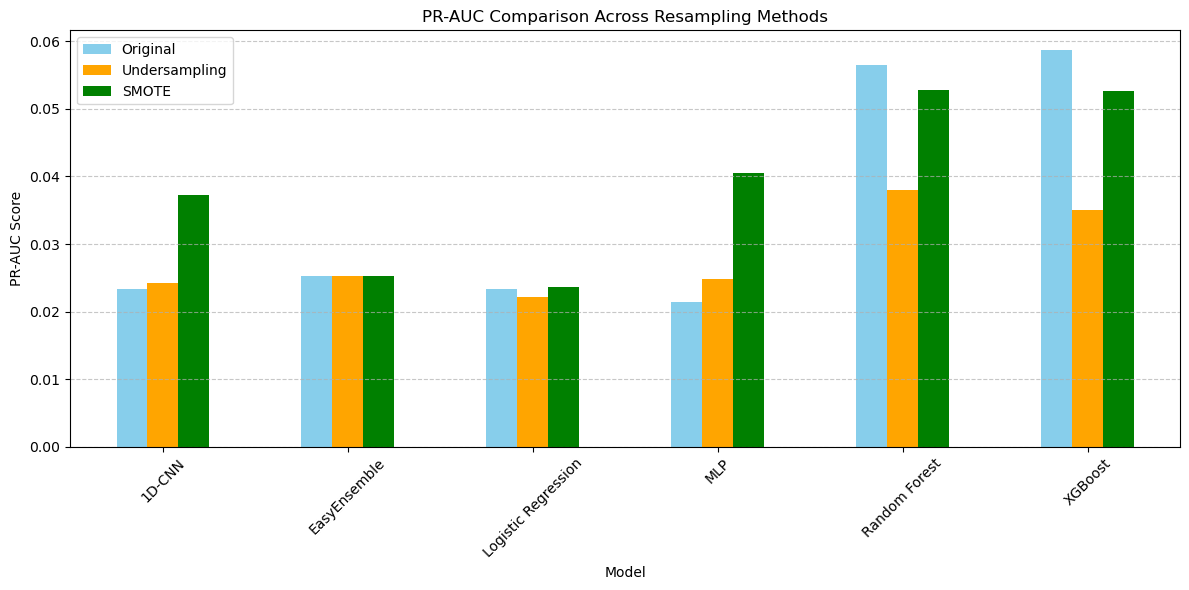

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load your existing result files
df_orig = pd.read_csv('kfold_default_results.csv')
df_rus  = pd.read_csv('kfold_undersample_results.csv')
df_smote = pd.read_csv('kfold_smote_results.csv')

# 2. Extract the PR-AUC for each model
comparison = pd.DataFrame({
    'Original': df_orig.set_index('Model')['PR-AUC'],
    'Undersampling': df_rus.set_index('Model')['PR-AUC'],
    'SMOTE': df_smote.set_index('Model')['PR-AUC']
})

# 3. Plot the comparison bar chart
comparison.plot(kind='bar', figsize=(12, 6), color=['skyblue', 'orange', 'green'])
plt.title('PR-AUC Comparison Across Resampling Methods')
plt.ylabel('PR-AUC Score')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Optimizing LR...
  Best params: {'C': 0.0005910577501863925}
  Best PR-AUC: 0.7824
Optimizing RF...
  Best params: {'n': 74, 'd': 15}
  Best PR-AUC: 0.9966
Optimizing XGB...
  Best params: {'n': 188, 'lr': 0.22716863835700732}
  Best PR-AUC: 0.9994
Optimizing EE...
  Best params: {'n': 41}
  Best PR-AUC: 0.9074
Optimizing MLP...
  Best params: {'h1': 110}
  Best PR-AUC: 0.9952
Optimizing CNN...
  Best params: {'filters': 54}
  Best PR-AUC: 0.9547

All models optimized. Best parameters:
  LR: {'C': 0.0005910577501863925}
  RF: {'n': 74, 'd': 15}
  XGB: {'n': 188, 'lr': 0.22716863835700732}
  EE: {'n': 41}
  MLP: {'h1': 110}
  CNN: {'filters': 54}

════════════════════════════════════════════════════════════
  FOLD 1 / 5
════════════════════════════════════════════════════════════
  [LR] Recall=0.7273  Precision=0.0144  F1=0.0282  PR-AUC=0.0227  ROC-AUC=0.7780
  [RF] Recall=0.2424  Precision=0.0386  F1=0.0667  PR-AUC=0.0425  ROC-AUC=0.8141
  [XGB] Recall=0.0707  Precision=0.0795  F1=0.07

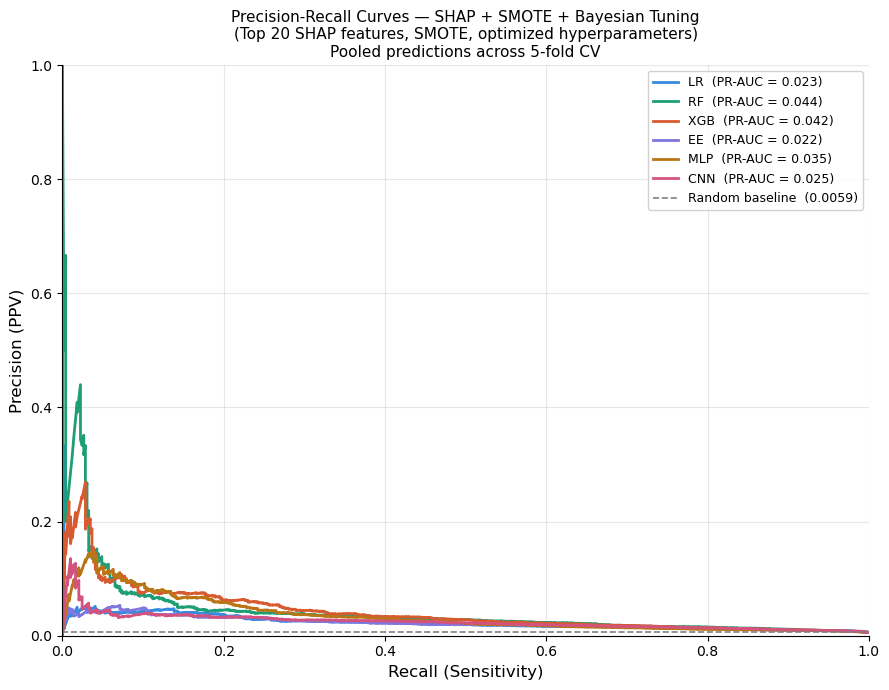

Saved: bayesian_tuning_pr_curve.png


In [37]:
# ══════════════════════════════════════════════════════
# BLOCK 8 — SHAP + SMOTE + Bayesian Hyperparameter Tuning
# All models: LR, RF, XGB, EE, MLP, CNN
# + SUMMARY TABLE (Mean ± Std) + PRECISION-RECALL CURVE
# ══════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from sklearn.model_selection import StratifiedKFold, train_test_split as tts
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from imblearn.ensemble import EasyEnsembleClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (average_precision_score,
                             roc_auc_score,
                             precision_recall_fscore_support,
                             precision_recall_curve)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
tf.get_logger().setLevel('ERROR')

# ── Color map ─────────────────────────────────────────
MODEL_COLORS = {
    'LR' : '#378ADD',
    'RF' : '#1D9E75',
    'XGB': '#D85A30',
    'EE' : '#7F77DD',
    'MLP': '#BA7517',
    'CNN': '#D4537E'
}

# ── 1. Setup ──────────────────────────────────────────
X_train_data = X_sel
y_train_data = y_all
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Storage for PR curve (pooled across all folds) ────
all_probs = {m: {'y_true': [], 'y_prob': []}
             for m in MODEL_COLORS}

# ── 2. Bayesian Optimization Objective ────────────────
def objective(trial, model_name, X, y):
    X_res, y_res = SMOTE(random_state=42).fit_resample(X, y)
    X_tr, X_val, y_tr, y_val = tts(
        X_res, y_res, test_size=0.2, random_state=42)

    if model_name == 'LR':
        C     = trial.suggest_float('C', 1e-4, 10, log=True)
        model = LogisticRegression(C=C, max_iter=1000)
        model.fit(X_tr, y_tr)
        return average_precision_score(
            y_val, model.predict_proba(X_val)[:, 1])

    elif model_name == 'RF':
        n     = trial.suggest_int('n', 50, 200)
        d     = trial.suggest_int('d', 3, 15)
        model = RandomForestClassifier(
            n_estimators=n, max_depth=d, n_jobs=-1)
        model.fit(X_tr, y_tr)
        return average_precision_score(
            y_val, model.predict_proba(X_val)[:, 1])

    elif model_name == 'XGB':
        n     = trial.suggest_int('n', 50, 200)
        lr    = trial.suggest_float('lr', 0.01, 0.3, log=True)
        model = XGBClassifier(
            n_estimators=n, learning_rate=lr,
            eval_metric='logloss', n_jobs=-1)
        model.fit(X_tr, y_tr)
        return average_precision_score(
            y_val, model.predict_proba(X_val)[:, 1])

    elif model_name == 'EE':
        n     = trial.suggest_int('n', 10, 100)
        model = EasyEnsembleClassifier(
            n_estimators=n, n_jobs=-1)
        model.fit(X_tr, y_tr)
        return average_precision_score(
            y_val, model.predict_proba(X_val)[:, 1])

    elif model_name == 'MLP':
        h1    = trial.suggest_int('h1', 32, 128)
        model = MLPClassifier(
            hidden_layer_sizes=(h1, 32), max_iter=500)
        model.fit(X_tr, y_tr)
        return average_precision_score(
            y_val, model.predict_proba(X_val)[:, 1])

    elif model_name == 'CNN':
        f     = trial.suggest_int('filters', 16, 64)
        model = Sequential([
            Conv1D(f, 3, activation='relu',
                   input_shape=(20, 1)),
            Flatten(),
            Dense(1, activation='sigmoid')
        ])
        model.compile(optimizer='adam',
                      loss='binary_crossentropy')
        model.fit(X_tr.reshape(-1, 20, 1), y_tr,
                  epochs=5, verbose=0)
        return average_precision_score(
            y_val,
            model.predict(
                X_val.reshape(-1, 20, 1),
                verbose=0).flatten())

# ── 3. Bayesian Optimization ──────────────────────────
best_params = {}
for m in MODEL_COLORS:
    print(f"Optimizing {m}...")
    study = optuna.create_study(direction='maximize')
    study.optimize(
        lambda trial: objective(
            trial, m, X_train_data, y_train_data),
        n_trials=10)
    best_params[m] = study.best_params
    print(f"  Best params: {study.best_params}")
    print(f"  Best PR-AUC: {study.best_value:.4f}")

print("\nAll models optimized. Best parameters:")
for m, p in best_params.items():
    print(f"  {m}: {p}")

# ── 4. Final Evaluation (Full Metrics per Fold) ───────
final_results = []

for fold, (train_idx, test_idx) in enumerate(
        skf.split(X_train_data, y_train_data)):

    print(f"\n{'═'*60}")
    print(f"  FOLD {fold+1} / 5")
    print(f"{'═'*60}")

    X_tr, X_te = X_train_data[train_idx], X_train_data[test_idx]
    y_tr, y_te = y_train_data[train_idx], y_train_data[test_idx]

    X_res, y_res = SMOTE(random_state=42).fit_resample(X_tr, y_tr)

    # ── Sklearn models ────────────────────────────────
    models = {
        'LR': LogisticRegression(
            C=best_params['LR']['C'], max_iter=1000),
        'RF': RandomForestClassifier(
            n_estimators=best_params['RF']['n'],
            max_depth=best_params['RF']['d'], n_jobs=-1),
        'XGB': XGBClassifier(
            n_estimators=best_params['XGB']['n'],
            learning_rate=best_params['XGB']['lr'],
            eval_metric='logloss', n_jobs=-1),
        'EE': EasyEnsembleClassifier(
            n_estimators=best_params['EE']['n'],
            n_jobs=-1),
        'MLP': MLPClassifier(
            hidden_layer_sizes=(best_params['MLP']['h1'], 32),
            max_iter=500)
    }

    for name, model in models.items():
        model.fit(X_res, y_res)
        preds = model.predict(X_te)
        probs = model.predict_proba(X_te)[:, 1]
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_te, preds, average='binary', zero_division=0)
        pr_auc  = average_precision_score(y_te, probs)
        roc_auc = roc_auc_score(y_te, probs)

        print(f"  [{name}] Recall={rec:.4f}  "
              f"Precision={prec:.4f}  "
              f"F1={f1:.4f}  "
              f"PR-AUC={pr_auc:.4f}  "
              f"ROC-AUC={roc_auc:.4f}")

        final_results.append({
            'Fold': fold, 'Model': name,
            'PR-AUC': pr_auc, 'ROC-AUC': roc_auc,
            'Precision': prec, 'Recall': rec, 'F1': f1
        })

        # Accumulate for PR curve
        all_probs[name]['y_true'].extend(y_te)
        all_probs[name]['y_prob'].extend(probs)

    # ── CNN ───────────────────────────────────────────
    cnn = Sequential([
        Conv1D(best_params['CNN']['filters'], 3,
               activation='relu', input_shape=(20, 1)),
        Flatten(),
        Dense(1, activation='sigmoid')
    ])
    cnn.compile(optimizer='adam', loss='binary_crossentropy')
    cnn.fit(X_res.reshape(-1, 20, 1), y_res,
            epochs=10, verbose=0)
    cnn_probs = cnn.predict(
        X_te.reshape(-1, 20, 1), verbose=0).flatten()
    cnn_preds = (cnn_probs > 0.5).astype(int)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_te, cnn_preds, average='binary', zero_division=0)
    pr_auc  = average_precision_score(y_te, cnn_probs)
    roc_auc = roc_auc_score(y_te, cnn_probs)

    print(f"  [CNN] Recall={rec:.4f}  "
          f"Precision={prec:.4f}  "
          f"F1={f1:.4f}  "
          f"PR-AUC={pr_auc:.4f}  "
          f"ROC-AUC={roc_auc:.4f}")

    final_results.append({
        'Fold': fold, 'Model': 'CNN',
        'PR-AUC': pr_auc, 'ROC-AUC': roc_auc,
        'Precision': prec, 'Recall': rec, 'F1': f1
    })

    all_probs['CNN']['y_true'].extend(y_te)
    all_probs['CNN']['y_prob'].extend(cnn_probs)

# ══════════════════════════════════════════════════════
# 5. PERFORMANCE BY FOLD
# ══════════════════════════════════════════════════════
df_final = pd.DataFrame(final_results)
print("\n--- PERFORMANCE BY FOLD ---")
print(df_final.to_string())

# ══════════════════════════════════════════════════════
# 6. MEAN ONLY SUMMARY
# ══════════════════════════════════════════════════════
print("\n--- MEAN PERFORMANCE SUMMARY ---")
mean_df = (df_final
           .groupby('Model')[['PR-AUC','ROC-AUC',
                              'Precision','Recall','F1']]
           .mean()
           .sort_values('PR-AUC', ascending=False))
print(mean_df.round(4).to_string())

# ══════════════════════════════════════════════════════
# 7. MEAN ± STD SUMMARY TABLE
# ══════════════════════════════════════════════════════
print(f"\n{'═'*60}")
print("  FINAL SUMMARY — Mean ± Std (5-Fold CV, Bayesian Tuning)")
print(f"{'═'*60}")

summary_rows = []
for model_name in MODEL_COLORS:
    df_m = df_final[df_final['Model'] == model_name]
    row  = {'Model': model_name}
    for metric in ['Recall','Precision','F1','PR-AUC','ROC-AUC']:
        mean = df_m[metric].mean()
        std  = df_m[metric].std()
        row[metric] = f"{mean:.4f} ± {std:.4f}"
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Model')
print(summary_df.to_string())

# ── Save results ──────────────────────────────────────
df_final.to_csv('kfold_bayesian_tuning_results.csv', index=False)
mean_df.to_csv('kfold_bayesian_tuning_mean.csv')
print("\nSaved: kfold_bayesian_tuning_results.csv")
print("Saved: kfold_bayesian_tuning_mean.csv")

# ══════════════════════════════════════════════════════
# 8. PRECISION-RECALL CURVE — all 6 models in one plot
# Pooled predictions across all 5 folds
# ══════════════════════════════════════════════════════
baseline_rate = y_all.sum() / len(y_all)

fig, ax = plt.subplots(figsize=(9, 7))

for model_name in MODEL_COLORS:
    y_true = np.array(all_probs[model_name]['y_true'])
    y_prob = np.array(all_probs[model_name]['y_prob'])

    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    pr_auc       = average_precision_score(y_true, y_prob)

    ax.plot(rec, prec,
            color=MODEL_COLORS[model_name],
            linewidth=2,
            label=f'{model_name}  (PR-AUC = {pr_auc:.3f})')

ax.axhline(y=baseline_rate,
           color='gray', linestyle='--', linewidth=1.2,
           label=f'Random baseline  ({baseline_rate:.4f})')

ax.set_xlabel('Recall (Sensitivity)', fontsize=12)
ax.set_ylabel('Precision (PPV)', fontsize=12)
ax.set_title(
    'Precision-Recall Curves — SHAP + SMOTE + Bayesian Tuning\n'
    '(Top 20 SHAP features, SMOTE, optimized hyperparameters)\n'
    'Pooled predictions across 5-fold CV',
    fontsize=11)
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('bayesian_tuning_pr_curve.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("Saved: bayesian_tuning_pr_curve.png")

Threshold (max F1)          : 0.2111
Threshold (recall>=0.70)    : 0.0063

At F1-optimal threshold:
  Precision : 0.0754
  Recall    : 0.1752
  F1        : 0.1055


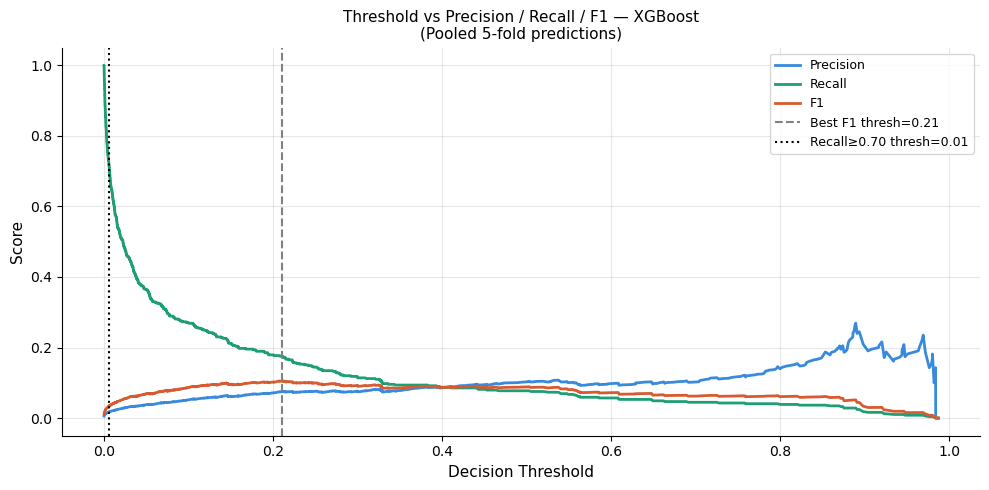

In [38]:
# ══════════════════════════════════════════════════════
# THRESHOLD OPTIMIZATION — on best model (XGBoost)
# Find optimal threshold using PR curve on pooled folds
# ══════════════════════════════════════════════════════
from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np

# Use pooled predictions from Block 8 (best experiment)
y_true_pool = np.array(all_probs['XGB']['y_true'])
y_prob_pool = np.array(all_probs['XGB']['y_prob'])

prec, rec, thresholds = precision_recall_curve(
    y_true_pool, y_prob_pool)

# Option A — threshold that maximises F1
f1_scores   = 2 * prec * rec / (prec + rec + 1e-8)
best_idx_f1 = np.argmax(f1_scores)
thresh_f1   = thresholds[best_idx_f1]

# Option B — threshold where recall >= 0.70, maximise precision
mask        = rec[:-1] >= 0.70
thresh_rec  = thresholds[mask][np.argmax(prec[:-1][mask])] \
              if mask.any() else thresh_f1

print(f"Threshold (max F1)          : {thresh_f1:.4f}")
print(f"Threshold (recall>=0.70)    : {thresh_rec:.4f}")
print(f"\nAt F1-optimal threshold:")
print(f"  Precision : {prec[best_idx_f1]:.4f}")
print(f"  Recall    : {rec[best_idx_f1]:.4f}")
print(f"  F1        : {f1_scores[best_idx_f1]:.4f}")

# Plot threshold vs precision/recall/F1
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, prec[:-1], color='#378ADD',
        linewidth=2, label='Precision')
ax.plot(thresholds, rec[:-1],  color='#1D9E75',
        linewidth=2, label='Recall')
ax.plot(thresholds, f1_scores[:-1], color='#D85A30',
        linewidth=2, label='F1')
ax.axvline(thresh_f1,  color='gray',
           linestyle='--', label=f'Best F1 thresh={thresh_f1:.2f}')
ax.axvline(thresh_rec, color='black',
           linestyle=':', label=f'Recall≥0.70 thresh={thresh_rec:.2f}')
ax.set_xlabel('Decision Threshold', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Threshold vs Precision / Recall / F1 — XGBoost\n'
             '(Pooled 5-fold predictions)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('threshold_optimization.png', dpi=150,
            bbox_inches='tight')
plt.show()

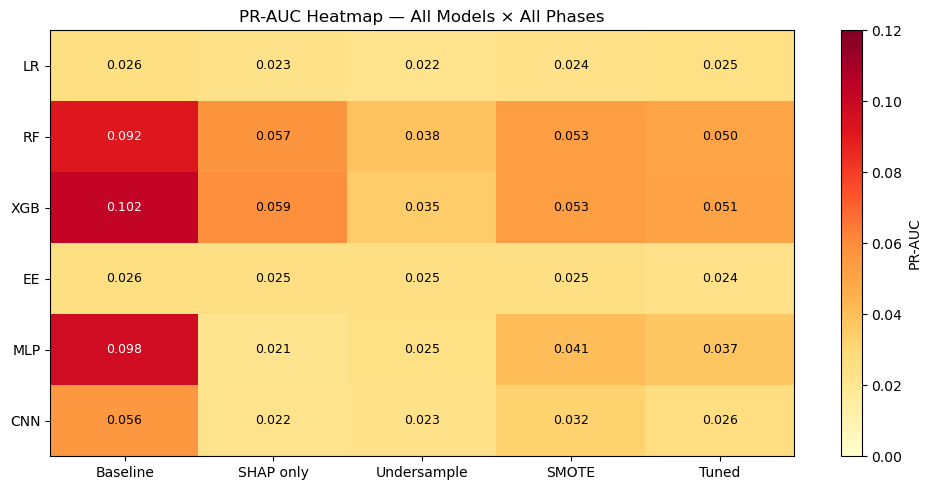

Saved: plot1_prauc_heatmap.png


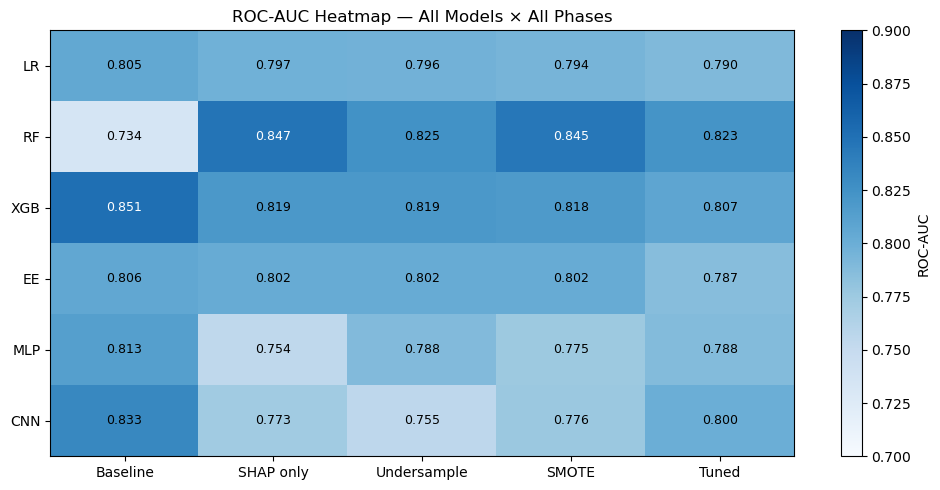

Saved: plot2_rocauc_heatmap.png


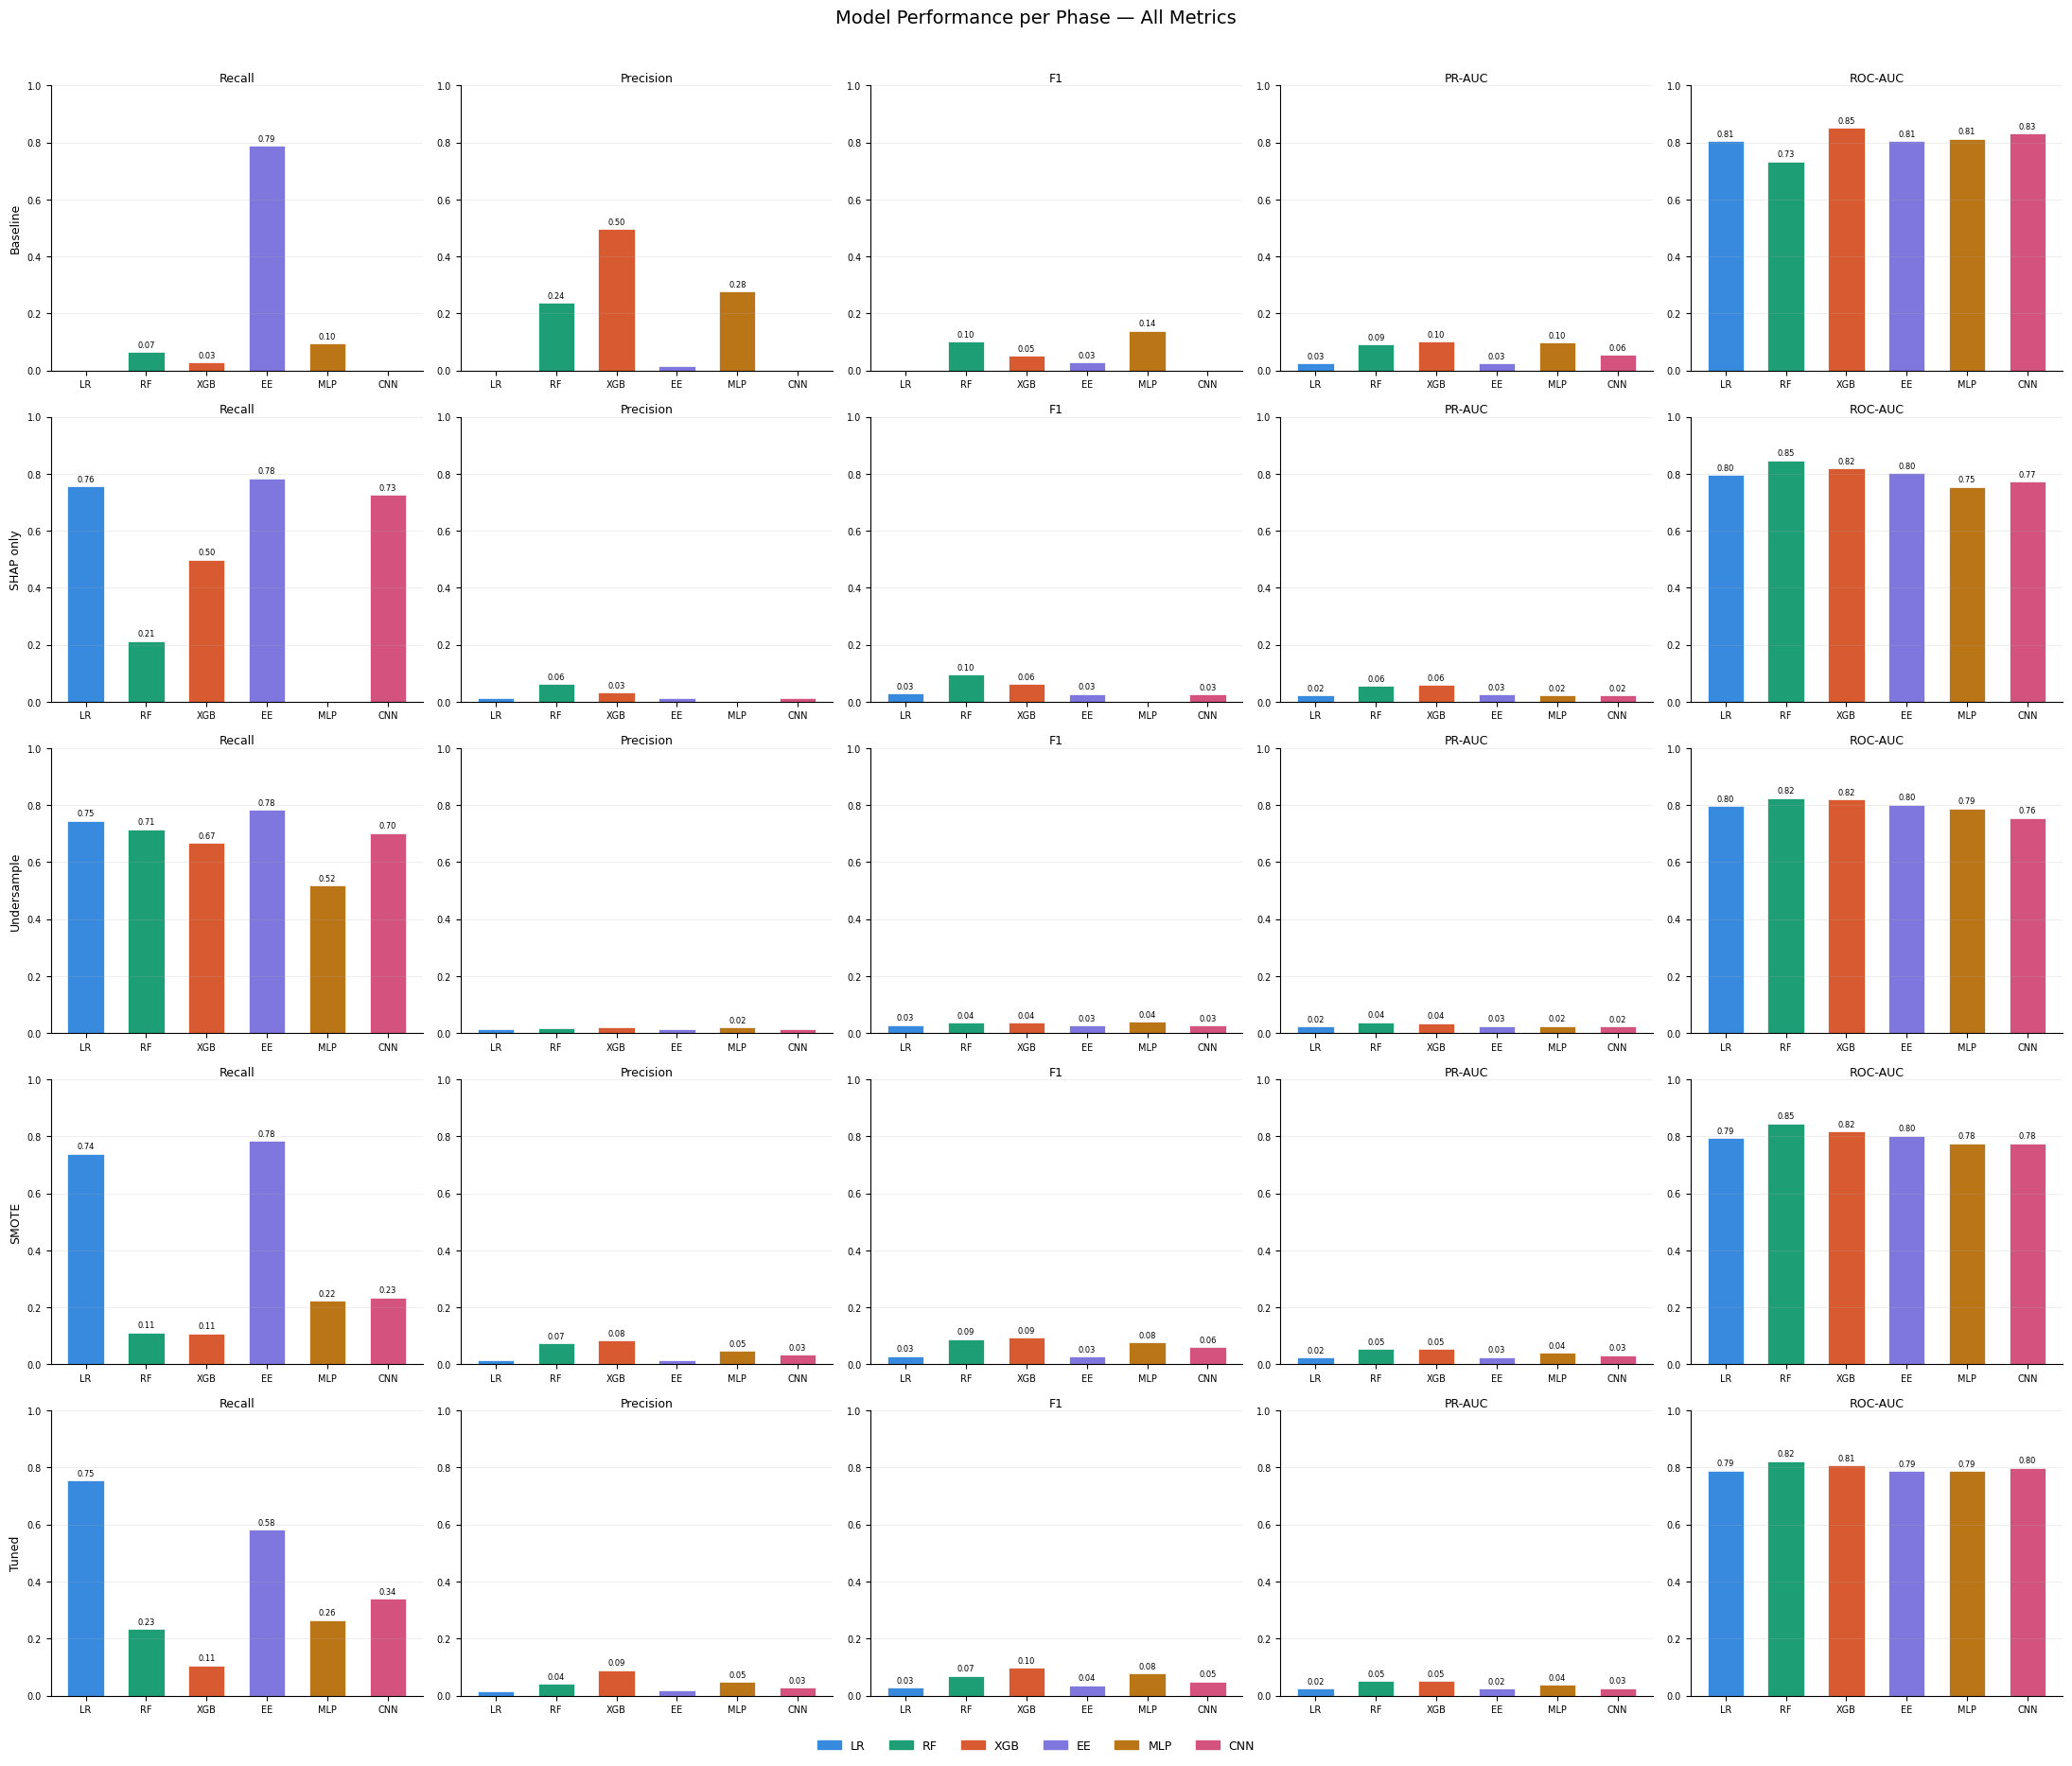

Saved: plot3_all_metrics_per_phase.png


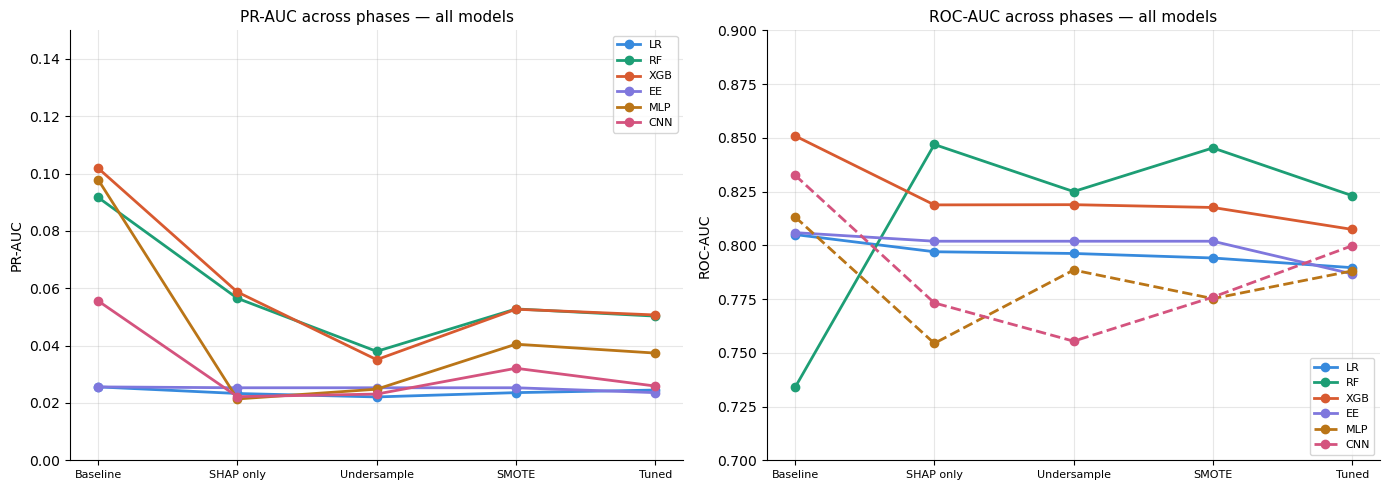

Saved: plot4_prauc_rocauc_trends.png


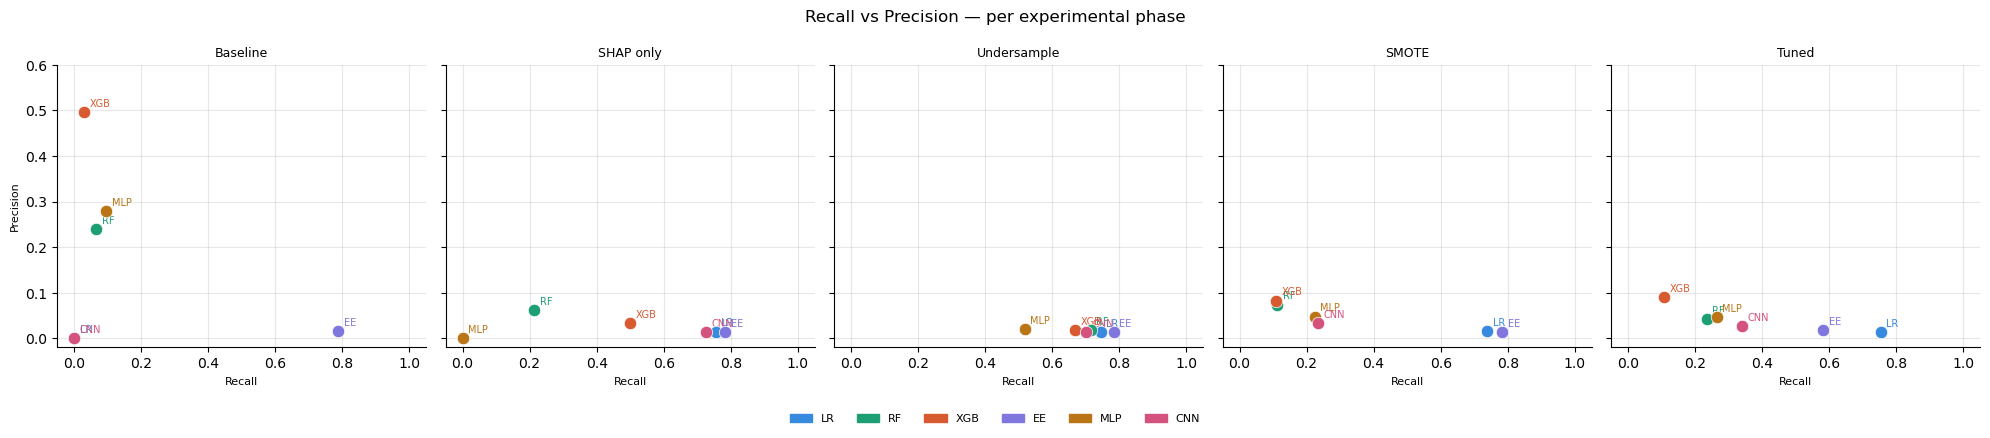

Saved: plot5_recall_precision_scatter.png


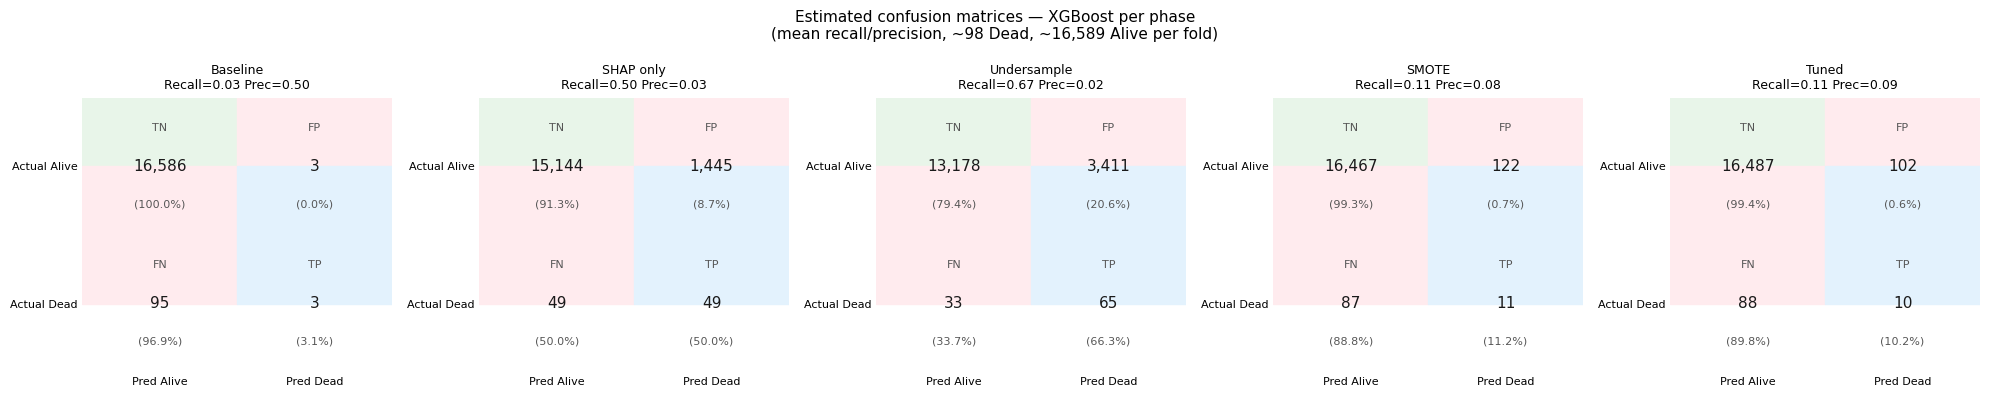

Saved: plot6_confusion_matrices.png


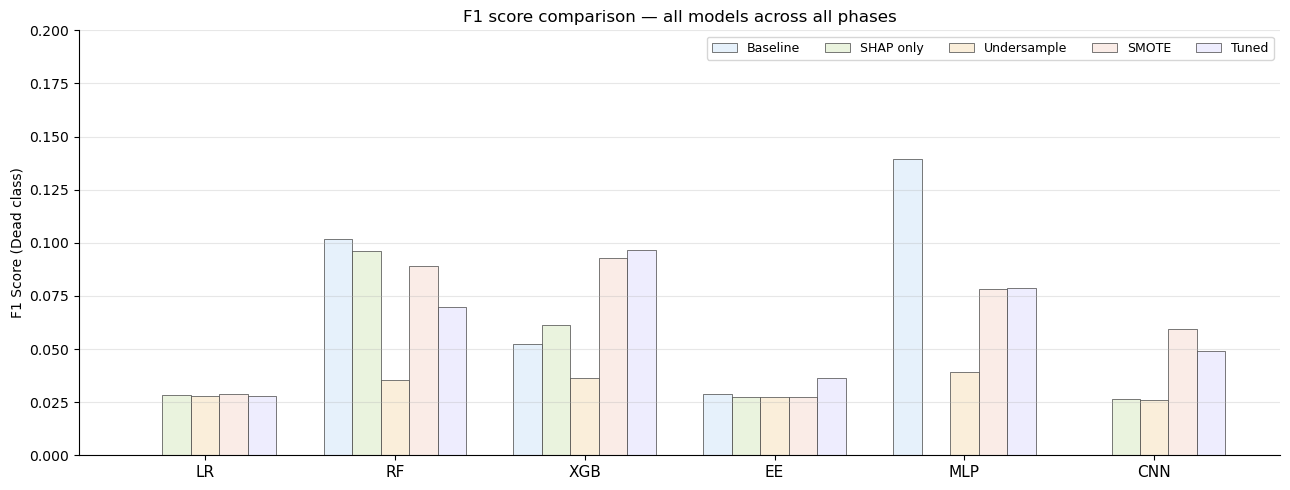

Saved: plot7_f1_comparison.png


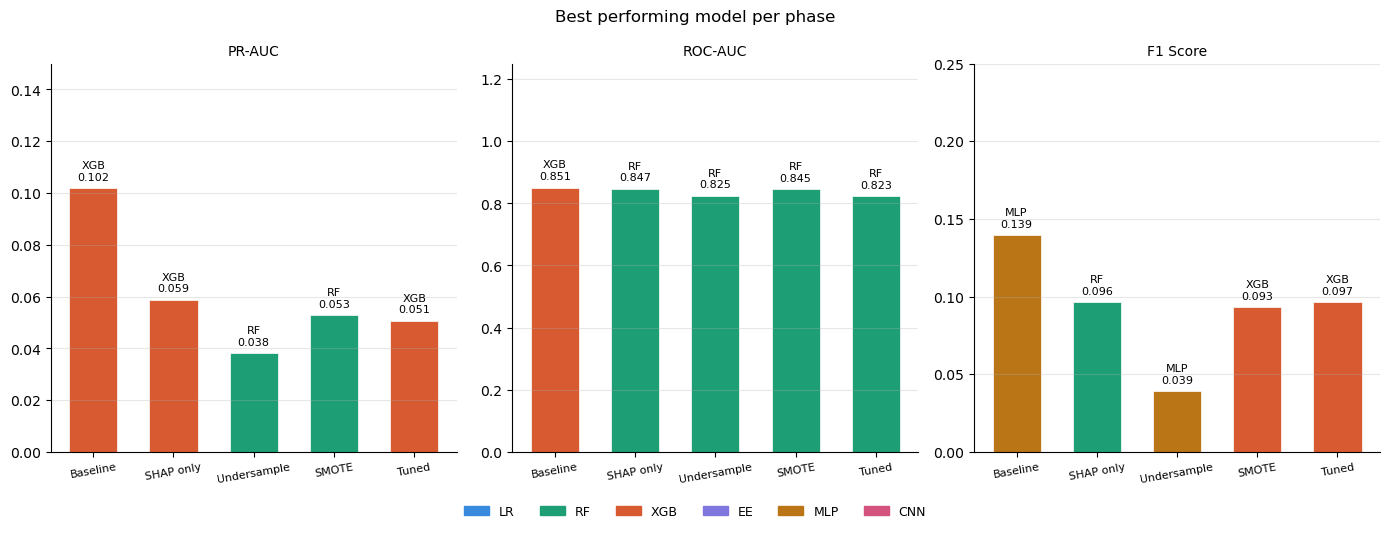

Saved: plot8_best_per_phase.png


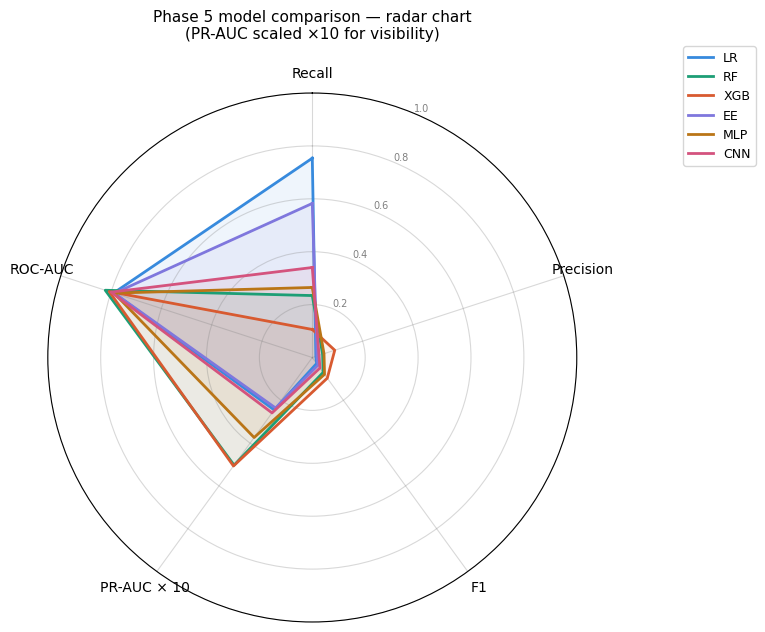

Saved: plot9_radar_phase5.png


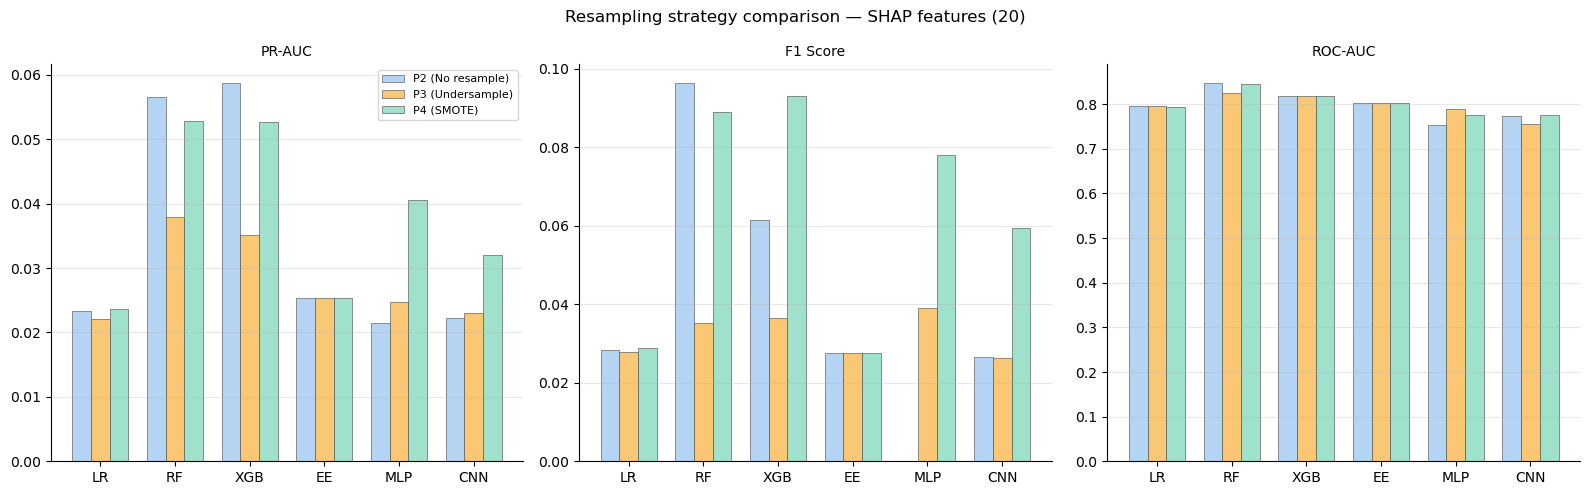

Saved: plot10_resampling_comparison.png

ALL PLOTS SAVED:
  plot1_prauc_heatmap.png                    PR-AUC heatmap — models × phases
  plot2_rocauc_heatmap.png                   ROC-AUC heatmap — models × phases
  plot3_all_metrics_per_phase.png            All metrics (5×5 grid)
  plot4_prauc_rocauc_trends.png              PR-AUC & ROC-AUC trend lines
  plot5_recall_precision_scatter.png         Recall vs Precision scatter
  plot6_confusion_matrices.png               Confusion matrices (XGBoost)
  plot7_f1_comparison.png                    F1 grouped bar — all phases
  plot8_best_per_phase.png                   Best model per phase
  plot9_radar_phase5.png                     Radar chart — Phase 5 models
  plot10_resampling_comparison.png           Resampling strategy comparison


In [39]:
# ══════════════════════════════════════════════════════════════════
# COMPREHENSIVE RESULTS VISUALIZATION
# 5 Experimental Phases — All Models
# ══════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════════════
# SECTION 1 — RESULTS DATA (from your experiment outputs)
# ══════════════════════════════════════════════════════════════════
MODELS   = ['LR', 'RF', 'XGB', 'EE', 'MLP', 'CNN']
PHASES   = ['P1\nBaseline', 'P2\nSHAP only', 'P3\nUndersample',
            'P4\nSMOTE', 'P5\nTuned']
COLORS   = {'LR':'#378ADD', 'RF':'#1D9E75', 'XGB':'#D85A30',
            'EE':'#7F77DD', 'MLP':'#BA7517', 'CNN':'#D4537E'}
PHASE_COLORS = ['#E6F1FB','#EAF3DE','#FAEEDA','#FAECE7','#EEEDFE']

# ── Mean metrics per phase per model ─────────────────────────────
results = {
    'P1': {  # Baseline — all 46 features, no resampling
        'LR' : dict(recall=0.0000,precision=0.0000,f1=0.0000,prauc=0.0256,rocauc=0.8050),
        'RF' : dict(recall=0.0652,precision=0.2387,f1=0.1016,prauc=0.0917,rocauc=0.7339),
        'XGB': dict(recall=0.0285,precision=0.4972,f1=0.0526,prauc=0.1019,rocauc=0.8509),
        'EE' : dict(recall=0.7882,precision=0.0147,f1=0.0287,prauc=0.0256,rocauc=0.8059),
        'MLP': dict(recall=0.0957,precision=0.2785,f1=0.1394,prauc=0.0979,rocauc=0.8132),
        'CNN': dict(recall=0.0000,precision=0.0000,f1=0.0000,prauc=0.0556,rocauc=0.8326),
    },
    'P2': {  # SHAP feature selection (20 features, no resampling)
        'LR' : dict(recall=0.7556,precision=0.0144,f1=0.0283,prauc=0.0233,rocauc=0.7970),
        'RF' : dict(recall=0.2138,precision=0.0622,f1=0.0963,prauc=0.0565,rocauc=0.8469),
        'XGB': dict(recall=0.4990,precision=0.0328,f1=0.0615,prauc=0.0587,rocauc=0.8188),
        'EE' : dict(recall=0.7841,precision=0.0140,f1=0.0275,prauc=0.0253,rocauc=0.8019),
        'MLP': dict(recall=0.0000,precision=0.0000,f1=0.0000,prauc=0.0214,rocauc=0.7544),
        'CNN': dict(recall=0.7272,precision=0.0135,f1=0.0265,prauc=0.0222,rocauc=0.7732),
    },
    'P3': {  # SHAP + Random Undersampling
        'LR' : dict(recall=0.7454,precision=0.0142,f1=0.0279,prauc=0.0221,rocauc=0.7962),
        'RF' : dict(recall=0.7149,precision=0.0181,f1=0.0353,prauc=0.0380,rocauc=0.8250),
        'XGB': dict(recall=0.6681,precision=0.0187,f1=0.0364,prauc=0.0351,rocauc=0.8189),
        'EE' : dict(recall=0.7841,precision=0.0140,f1=0.0275,prauc=0.0253,rocauc=0.8019),
        'MLP': dict(recall=0.5176,precision=0.0203,f1=0.0390,prauc=0.0248,rocauc=0.7885),
        'CNN': dict(recall=0.7022,precision=0.0134,f1=0.0262,prauc=0.0231,rocauc=0.7554),
    },
    'P4': {  # SHAP + SMOTE
        'LR' : dict(recall=0.7393,precision=0.0147,f1=0.0288,prauc=0.0236,rocauc=0.7941),
        'RF' : dict(recall=0.1120,precision=0.0738,f1=0.0889,prauc=0.0528,rocauc=0.8453),
        'XGB': dict(recall=0.1081,precision=0.0827,f1=0.0930,prauc=0.0527,rocauc=0.8176),
        'EE' : dict(recall=0.7841,precision=0.0140,f1=0.0275,prauc=0.0253,rocauc=0.8019),
        'MLP': dict(recall=0.2241,precision=0.0474,f1=0.0781,prauc=0.0405,rocauc=0.7752),
        'CNN': dict(recall=0.2342,precision=0.0341,f1=0.0595,prauc=0.0321,rocauc=0.7759),
    },
    'P5': {  # SHAP + SMOTE + Bayesian Tuning
        'LR' : dict(recall=0.7536,precision=0.0142,f1=0.0279,prauc=0.0245,rocauc=0.7896),
        'RF' : dict(recall=0.2342,precision=0.0410,f1=0.0697,prauc=0.0503,rocauc=0.8231),
        'XGB': dict(recall=0.1060,precision=0.0893,f1=0.0965,prauc=0.0507,rocauc=0.8074),
        'EE' : dict(recall=0.5826,precision=0.0187,f1=0.0362,prauc=0.0236,rocauc=0.7867),
        'MLP': dict(recall=0.2648,precision=0.0466,f1=0.0787,prauc=0.0374,rocauc=0.7881),
        'CNN': dict(recall=0.3403,precision=0.0268,f1=0.0492,prauc=0.0259,rocauc=0.7998),
    }
}

# ── Helper: extract metric matrix ────────────────────────────────
def get_matrix(metric):
    """Returns (6 models × 5 phases) array for a given metric."""
    phases = ['P1','P2','P3','P4','P5']
    mat = np.array([[results[p][m][metric] for p in phases]
                    for m in MODELS])
    return mat

# ══════════════════════════════════════════════════════════════════
# PLOT 1 — HEATMAP: PR-AUC across all models and phases
# ══════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))
mat = get_matrix('prauc')
im  = ax.imshow(mat, cmap='YlOrRd', aspect='auto', vmin=0, vmax=0.12)
ax.set_xticks(range(5))
ax.set_xticklabels(['Baseline','SHAP only','Undersample','SMOTE','Tuned'],
                   fontsize=10)
ax.set_yticks(range(6))
ax.set_yticklabels(MODELS, fontsize=10)
ax.set_title('PR-AUC Heatmap — All Models × All Phases', fontsize=12)
for i in range(6):
    for j in range(5):
        val = mat[i, j]
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=9,
                color='white' if val > 0.07 else 'black')
plt.colorbar(im, ax=ax, label='PR-AUC')
plt.tight_layout()
plt.savefig('plot1_prauc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot1_prauc_heatmap.png")

# ══════════════════════════════════════════════════════════════════
# PLOT 2 — HEATMAP: ROC-AUC across all models and phases
# ══════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))
mat = get_matrix('rocauc')
im  = ax.imshow(mat, cmap='Blues', aspect='auto', vmin=0.70, vmax=0.90)
ax.set_xticks(range(5))
ax.set_xticklabels(['Baseline','SHAP only','Undersample','SMOTE','Tuned'],
                   fontsize=10)
ax.set_yticks(range(6))
ax.set_yticklabels(MODELS, fontsize=10)
ax.set_title('ROC-AUC Heatmap — All Models × All Phases', fontsize=12)
for i in range(6):
    for j in range(5):
        val = mat[i, j]
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=9,
                color='white' if val > 0.84 else 'black')
plt.colorbar(im, ax=ax, label='ROC-AUC')
plt.tight_layout()
plt.savefig('plot2_rocauc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot2_rocauc_heatmap.png")

# ══════════════════════════════════════════════════════════════════
# PLOT 3 — BAR CHART: All metrics per phase (grouped by model)
# ══════════════════════════════════════════════════════════════════
metrics    = ['recall','precision','f1','prauc','rocauc']
m_labels   = ['Recall','Precision','F1','PR-AUC','ROC-AUC']
phase_keys = ['P1','P2','P3','P4','P5']
phase_full = ['Baseline','SHAP only','Undersample','SMOTE','Tuned']

fig, axes = plt.subplots(5, 5, figsize=(22, 18), sharey=False)
fig.suptitle('Model Performance per Phase — All Metrics',
             fontsize=14, fontweight='normal', y=1.01)

for pi, (pk, pf) in enumerate(zip(phase_keys, phase_full)):
    for mi, (mk, ml) in enumerate(zip(metrics, m_labels)):
        ax  = axes[pi][mi]
        vals = [results[pk][m][mk] for m in MODELS]
        bars = ax.bar(MODELS, vals,
                      color=[COLORS[m] for m in MODELS],
                      width=0.6, edgecolor='white', linewidth=0.5)
        ax.set_ylim(0, 1.0)
        ax.set_title(f'{ml}', fontsize=9, pad=3)
        ax.tick_params(axis='x', labelsize=7)
        ax.tick_params(axis='y', labelsize=7)
        ax.spines[['top','right']].set_visible(False)
        ax.grid(axis='y', alpha=0.3, linewidth=0.5)
        for bar, val in zip(bars, vals):
            if val > 0.02:
                ax.text(bar.get_x() + bar.get_width()/2,
                        val + 0.01, f'{val:.2f}',
                        ha='center', va='bottom', fontsize=6)
        if mi == 0:
            ax.set_ylabel(pf, fontsize=9, fontweight='normal',
                         rotation=90, labelpad=4)

legend_patches = [Patch(color=COLORS[m], label=m) for m in MODELS]
fig.legend(handles=legend_patches, loc='lower center',
           ncol=6, fontsize=9, frameon=False,
           bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.savefig('plot3_all_metrics_per_phase.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("Saved: plot3_all_metrics_per_phase.png")

# ══════════════════════════════════════════════════════════════════
# PLOT 4 — LINE CHART: PR-AUC trend across phases per model
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR-AUC trend
ax = axes[0]
for m in MODELS:
    vals = [results[p][m]['prauc'] for p in phase_keys]
    ax.plot(phase_full, vals, marker='o', label=m,
            color=COLORS[m], linewidth=2, markersize=6)
ax.set_title('PR-AUC across phases — all models', fontsize=11)
ax.set_ylabel('PR-AUC', fontsize=10)
ax.set_ylim(0, 0.15)
ax.tick_params(axis='x', labelsize=8)
ax.spines[['top','right']].set_visible(False)
ax.grid(alpha=0.3)
ax.legend(fontsize=8, loc='upper right')

# ROC-AUC trend
ax = axes[1]
for m in MODELS:
    vals = [results[p][m]['rocauc'] for p in phase_keys]
    ax.plot(phase_full, vals, marker='o', label=m,
            color=COLORS[m], linewidth=2, markersize=6,
            linestyle='--' if m in ['MLP','CNN'] else '-')
ax.set_title('ROC-AUC across phases — all models', fontsize=11)
ax.set_ylabel('ROC-AUC', fontsize=10)
ax.set_ylim(0.70, 0.90)
ax.tick_params(axis='x', labelsize=8)
ax.spines[['top','right']].set_visible(False)
ax.grid(alpha=0.3)
ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('plot4_prauc_rocauc_trends.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("Saved: plot4_prauc_rocauc_trends.png")

# ══════════════════════════════════════════════════════════════════
# PLOT 5 — RECALL vs PRECISION scatter per phase
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
fig.suptitle('Recall vs Precision — per experimental phase',
             fontsize=12, fontweight='normal')

for pi, (pk, pf) in enumerate(zip(phase_keys, phase_full)):
    ax = axes[pi]
    for m in MODELS:
        r = results[pk][m]['recall']
        p = results[pk][m]['precision']
        ax.scatter(r, p, color=COLORS[m], s=80, zorder=5,
                   label=m, edgecolors='white', linewidth=0.5)
        ax.annotate(m, (r, p), textcoords='offset points',
                    xytext=(4, 4), fontsize=7,
                    color=COLORS[m])
    ax.set_title(pf, fontsize=9)
    ax.set_xlabel('Recall', fontsize=8)
    if pi == 0:
        ax.set_ylabel('Precision', fontsize=8)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.02, 0.60)
    ax.spines[['top','right']].set_visible(False)
    ax.grid(alpha=0.3)

legend_patches = [Patch(color=COLORS[m], label=m) for m in MODELS]
fig.legend(handles=legend_patches, loc='lower center',
           ncol=6, fontsize=8, frameon=False,
           bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.savefig('plot5_recall_precision_scatter.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("Saved: plot5_recall_precision_scatter.png")

# ══════════════════════════════════════════════════════════════════
# PLOT 6 — CONFUSION MATRICES: Best model (XGBoost) per phase
# ══════════════════════════════════════════════════════════════════
DEAD_TEST  = 98
ALIVE_TEST = 16589

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Estimated confusion matrices — XGBoost per phase\n'
             '(mean recall/precision, ~98 Dead, ~16,589 Alive per fold)',
             fontsize=11, fontweight='normal')

cm_labels = [['TN','FP'],['FN','TP']]
cm_colors = [['#E8F5E9','#FFEBEE'],['#FFEBEE','#E3F2FD']]

for pi, (pk, pf) in enumerate(zip(phase_keys, phase_full)):
    ax    = axes[pi]
    rec   = results[pk]['XGB']['recall']
    prec  = results[pk]['XGB']['precision']
    tp    = int(round(rec * DEAD_TEST))
    fn    = DEAD_TEST - tp
    fp    = int(round(tp * (1 - prec) / prec)) if prec > 0 else 0
    tn    = ALIVE_TEST - fp
    mat   = np.array([[tn, fp],[fn, tp]])
    totals= [[ALIVE_TEST, ALIVE_TEST],[DEAD_TEST, DEAD_TEST]]

    for i in range(2):
        for j in range(2):
            ax.add_patch(plt.Rectangle((j-0.5, 1.5-i-0.5), 1, 1,
                         color=cm_colors[i][j]))
            val = mat[i][j]
            ax.text(j, 1-i, f'{val:,}', ha='center', va='center',
                    fontsize=11, fontweight='normal',
                    color='#1a1a1a')
            ax.text(j, 1-i-0.28,
                    f'({val/totals[i][j]*100:.1f}%)',
                    ha='center', va='center',
                    fontsize=8, color='#555')
            ax.text(j, 1-i+0.28, cm_labels[i][j],
                    ha='center', va='center',
                    fontsize=8, color='#555')

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Pred Alive','Pred Dead'], fontsize=8)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Actual Dead','Actual Alive'], fontsize=8)
    ax.set_title(f'{pf}\nRecall={rec:.2f} Prec={prec:.2f}',
                 fontsize=9)
    ax.spines[['top','right','bottom','left']].set_visible(False)
    ax.tick_params(length=0)

plt.tight_layout()
plt.savefig('plot6_confusion_matrices.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("Saved: plot6_confusion_matrices.png")

# ══════════════════════════════════════════════════════════════════
# PLOT 7 — GROUPED BAR: F1 comparison across phases
# ══════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 5))
x       = np.arange(len(MODELS))
width   = 0.15
offsets = np.linspace(-2, 2, 5) * width

for pi, (pk, pf, col) in enumerate(
        zip(phase_keys, phase_full, PHASE_COLORS)):
    vals = [results[pk][m]['f1'] for m in MODELS]
    bars = ax.bar(x + offsets[pi], vals, width,
                  label=pf, color=col,
                  edgecolor=['#444']*6, linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(MODELS, fontsize=11)
ax.set_ylabel('F1 Score (Dead class)', fontsize=10)
ax.set_title('F1 score comparison — all models across all phases',
             fontsize=12)
ax.set_ylim(0, 0.20)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=9, loc='upper right', ncol=5)
plt.tight_layout()
plt.savefig('plot7_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot7_f1_comparison.png")

# ══════════════════════════════════════════════════════════════════
# PLOT 8 — BEST MODEL PER PHASE: summary bar chart
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Best performing model per phase',
             fontsize=12, fontweight='normal')

for ax_i, (metric, label, ylim) in enumerate([
        ('prauc','PR-AUC',0.12),
        ('rocauc','ROC-AUC',1.0),
        ('f1','F1 Score',0.20)]):

    ax = axes[ax_i]
    best_vals  = []
    best_models= []
    best_colors= []

    for pk in phase_keys:
        best_m   = max(MODELS, key=lambda m: results[pk][m][metric])
        best_val = results[pk][best_m][metric]
        best_vals.append(best_val)
        best_models.append(best_m)
        best_colors.append(COLORS[best_m])

    bars = ax.bar(phase_full, best_vals, color=best_colors,
                  edgecolor='white', linewidth=0.5, width=0.6)
    for bar, val, model in zip(bars, best_vals, best_models):
        ax.text(bar.get_x() + bar.get_width()/2,
                val + ylim*0.02,
                f'{model}\n{val:.3f}',
                ha='center', va='bottom', fontsize=8)
    ax.set_title(label, fontsize=10)
    ax.set_ylim(0, ylim * 1.25)
    ax.tick_params(axis='x', labelsize=8, rotation=10)
    ax.spines[['top','right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

legend_patches = [Patch(color=COLORS[m], label=m) for m in MODELS]
fig.legend(handles=legend_patches, loc='lower center',
           ncol=6, fontsize=9, frameon=False,
           bbox_to_anchor=(0.5, -0.06))
plt.tight_layout()
plt.savefig('plot8_best_per_phase.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot8_best_per_phase.png")

# ══════════════════════════════════════════════════════════════════
# PLOT 9 — RADAR / SPIDER CHART: Phase 5 (best phase) all models
# ══════════════════════════════════════════════════════════════════
from matplotlib.patches import FancyArrowPatch

metrics_radar  = ['Recall','Precision','F1','PR-AUC × 10','ROC-AUC']
N = len(metrics_radar)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8),
                        subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_radar, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=7,
                   color='gray')
ax.grid(color='gray', alpha=0.3)

for m in MODELS:
    d = results['P5'][m]
    vals = [d['recall'], d['precision'], d['f1'],
            d['prauc'] * 10, d['rocauc']]
    vals += vals[:1]
    ax.plot(angles, vals, color=COLORS[m], linewidth=2, label=m)
    ax.fill(angles, vals, color=COLORS[m], alpha=0.08)

ax.set_title('Phase 5 model comparison — radar chart\n'
             '(PR-AUC scaled ×10 for visibility)',
             fontsize=11, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
plt.savefig('plot9_radar_phase5.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot9_radar_phase5.png")

# ══════════════════════════════════════════════════════════════════
# PLOT 10 — RESAMPLING STRATEGY COMPARISON (P2 vs P3 vs P4)
# Key models only: RF, XGB, MLP
# ══════════════════════════════════════════════════════════════════
key_models  = ['LR','RF','XGB','EE','MLP','CNN']
strategies  = ['P2\n(No resample)','P3\n(Undersample)','P4\n(SMOTE)']
strat_keys  = ['P2','P3','P4']
strat_colors= ['#B5D4F4','#FAC775','#9FE1CB']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Resampling strategy comparison — SHAP features (20)',
             fontsize=12, fontweight='normal')

for ax_i, (metric, label) in enumerate([
        ('prauc','PR-AUC'),
        ('f1','F1 Score'),
        ('rocauc','ROC-AUC')]):

    ax    = axes[ax_i]
    x     = np.arange(len(key_models))
    width = 0.25

    for si, (sk, sl, sc) in enumerate(
            zip(strat_keys, strategies, strat_colors)):
        vals = [results[sk][m][metric] for m in key_models]
        bars = ax.bar(x + (si-1)*width, vals, width,
                      label=sl.replace('\n',' '), color=sc,
                      edgecolor='#444', linewidth=0.4)

    ax.set_xticks(x)
    ax.set_xticklabels(key_models, fontsize=10)
    ax.set_title(label, fontsize=10)
    ax.spines[['top','right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3)
    if ax_i == 0:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('plot10_resampling_comparison.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("Saved: plot10_resampling_comparison.png")

# ══════════════════════════════════════════════════════════════════
# SUMMARY: list all saved plots
# ══════════════════════════════════════════════════════════════════
print("\n" + "="*55)
print("ALL PLOTS SAVED:")
print("="*55)
plots = [
    ("plot1_prauc_heatmap.png",        "PR-AUC heatmap — models × phases"),
    ("plot2_rocauc_heatmap.png",       "ROC-AUC heatmap — models × phases"),
    ("plot3_all_metrics_per_phase.png","All metrics (5×5 grid)"),
    ("plot4_prauc_rocauc_trends.png",  "PR-AUC & ROC-AUC trend lines"),
    ("plot5_recall_precision_scatter.png","Recall vs Precision scatter"),
    ("plot6_confusion_matrices.png",   "Confusion matrices (XGBoost)"),
    ("plot7_f1_comparison.png",        "F1 grouped bar — all phases"),
    ("plot8_best_per_phase.png",       "Best model per phase"),
    ("plot9_radar_phase5.png",         "Radar chart — Phase 5 models"),
    ("plot10_resampling_comparison.png","Resampling strategy comparison"),
]
for fname, desc in plots:
    print(f"  {fname:<42} {desc}")